In [29]:
import gc
import numpy as np
import os
import re
import sys

import pandas as pd
import tensorflow_data_validation as tfdv

#VERSION = "20221025"
DATA_DIR = r"Z:\13.Data Science\Projects\2022_GI_Xsell\Data"
PROJECT_DIR = "../"
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
META_DATA_DIR = os.path.join(DATA_DIR, "meta_and_reference_data")
VER_1025_DIR = os.path.join(RAW_DATA_DIR, "20221025")
VER_1118_DIR = os.path.join(RAW_DATA_DIR, "20221118")
VER_1122_DIR = os.path.join(RAW_DATA_DIR, "20221122")
VER_1212_DIR = os.path.join(RAW_DATA_DIR, "20221212")
GI_DATA_DIR = os.path.join(RAW_DATA_DIR, "GI")
PA_DATA_DIR = os.path.join(GI_DATA_DIR, "Travel", "202210")
sys.path.insert(0, DATA_DIR)
sys.path.insert(0, PROJECT_DIR)

from datetime import datetime
from dateutil.relativedelta import relativedelta

# from src.utils.common import PLAN_TYPE_LST, WGP_LST, INFORCE_STATUS_LST, TRAVEL_SINGLE_MULTI_TRIP_DICT
# from src.utils.helper_function import find_plan_type, one_hot

In [30]:
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [31]:
BASESTAT_FILE = os.path.join(PA_DATA_DIR, "basestat.parquet")
CLAMBASE_FILE = os.path.join(PA_DATA_DIR, "clambase.parquet")
PREMBASE_FILE = os.path.join(PA_DATA_DIR, "prembase.parquet")
CLIENT_DATA_MAPPING_FILE = os.path.join(PROCESSED_DATA_DIR, "processed_client_data.parquet")

In [32]:
prembase_df = pd.read_parquet(PREMBASE_FILE)

# convert column CCDATE, TRANDATE to datetime at prembase_df
prembase_df["OCCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")
prembase_df["CCDATE"] = pd.to_datetime(prembase_df["CCDATE"], format="%Y%m%d")
prembase_df["TRANDATE"] = pd.to_datetime(prembase_df["TRANDATE"], format="%Y%m%d")

# BASESTAT

In [19]:
basestat_df = pd.read_parquet(BASESTAT_FILE)


In [20]:
basestat_df.head(5)

,contrnb,CCDATE,RSKNO,DTEEFF,CNTTYPE,OCCDATE,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,ZDMIND,bulk,bulk_name,nbrn,tranat,product,bulk_name1,CLTSEX,INSURED,ZPLANCDE,trlarea,znolive,plan1,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,producer,rmisagent,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,gwp,nwp,gep,nep,yduration,disc,ypol,ypol_actual,no_pol,no_rsk,commis,commis_n,nec,if_pol,if_rsk,ExpectedCost,TechnicalPremium,MarketingPremium,GWP_initial,APTP_gp,chgbal_g,chgbal_n,paymnt_g,paymnt_n,nb_clm,incur_g,incur_n,ultincur_n,ult_clm,lrg_incur_g,lrg_incur_n,lrg_ultincur,if_znolive,Agg_CA_nb_clm,Agg_EA_nb_clm,Agg_ME_nb_clm,Agg_PA_nb_clm,Agg_PB_nb_clm,Agg_TD_nb_clm,Agg_TP_nb_clm,Agg_CA_ultclm,Agg_EA_ultclm,Agg_ME_ultclm,Agg_PA_ultclm,Agg_PB_ultclm,Agg_TD_ultclm,Agg_TP_ultclm,Agg_CA_incur_g,Agg_EA_incur_g,Agg_ME_incur_g,Agg_PA_incur_g,Agg_PB_incur_g,Agg_TD_incur_g,Agg_TP_incur_g,Agg_CA_incur_n,Agg_EA_incur_n,Agg_ME_incur_n,Agg_PA_incur_n,Agg_PB_incur_n,Agg_TD_incur_n,Agg_TP_incur_n,Agg_CA_ultincur,Agg_EA_ultincur,Agg_ME_ultincur,Agg_PA_ultincur,Agg_PB_ultincur,Agg_TD_ultincur,Agg_TP_ultincur,period,total_yduration,no_znolive
0,00301996,NaN,2.0,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20140101.0,0.0,0.0
1,00307066,NaN,2.0,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20140101.0,0.0,0.0
2,00310357,NaN,2.0,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20140101.0,0.0,0.0
3,00314982,NaN,2.0,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20140101.0,0.0,0.0
4,00319036,NaN,2.0,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20140101.0,0.0,0.0


In [21]:
# get useful columns from basestat_df 
useful_basestat=basestat_df[['contrnb','nb_clm','CCDATE','OCCDATE',"COWNNUM",'product','plan1','duration','duration_grp','channel','GWP_initial','period']]


In [25]:
# show rows where nb_clm is 5
useful_basestat[useful_basestat['nb_clm']==1].sample()

,contrnb,nb_clm,CCDATE,OCCDATE,COWNNUM,product,plan1,duration,duration_grp,channel,GWP_initial,period
4937676,25983560,1.0,20210430.0,20210430.0,6040947,Multi Trip 2018,Annual,365.0,Annual,Banca - HSBC,0.0,20220101.0


In [15]:
DUMMY_ID=['unknown','A123456','F123456']

In [16]:
#drop if contrnb is in DUMMY_ID
useful_basestat=useful_basestat[~useful_basestat['contrnb'].isin(DUMMY_ID)]




In [24]:

basestat_df['product'].value_counts()

TravelSurance (single trip)                  2174945
SmartTraveller (Single)                       830363
Single Trip 2018                              670698
MultiTrip TravelSurance (Annual)              656180
SmartTraveller (Annual)                       222276
Multi Trip 2018                               210808
UNICOVER OVERSEAS STUDENT INS                  96840
MultiTrip TravelSurance (Monthly payment)      74798
SmartTraveller Plus (Single)                   38049
SmartTraveller- Citi                           36969
BUSINESS TRAVELCARE                            17586
Group Biz Travel                               15166
SmartTraveller Plus (Annual)                   11734
Overseas StudySurance                           9309
Supreme Travel                                  6699
CITIPOINT Scheme                                4225
JLT Travel                                      3716
GROUP TRAVEL COVER                              1107
AON Scheme                                    

In [215]:
#group by channel then group by products then count number of unique contrnb
basestat_df.groupby('channel')['product'].value_counts()

channel             product                                  
AXA Offline Direct  SmartTraveller (Single)                        16723
                    SmartTraveller (Annual)                         7266
                    UNICOVER OVERSEAS STUDENT INS                   4622
                    SmartTraveller Plus (Single)                      78
                    SmartTraveller Plus (Annual)                      74
AXA Online Direct   SmartTraveller (Single)                        88053
                    SmartTraveller Plus (Single)                   19517
                    UNICOVER OVERSEAS STUDENT INS                   9970
                    SmartTraveller (Annual)                         8012
                    SmartTraveller Plus (Annual)                    4375
Agents & Broker     SmartTraveller (Single)                       397139
                    SmartTraveller (Annual)                       120669
                    Group Biz Travel                          

<AxesSubplot:xlabel='channel'>

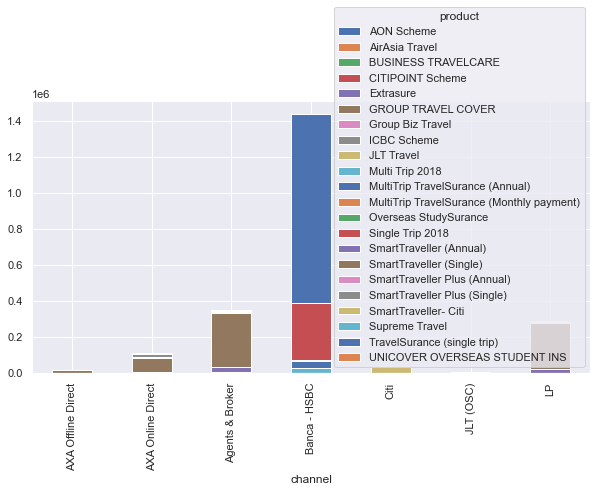

In [222]:
basestat_df.drop_duplicates(subset='contrnb').groupby('channel')['product'].value_counts()
# Translate to comment:basestat_df.drop_duplicates(subset='contrnb').groupby('channel')['product'].value_counts()
# drop duplicate rows base on contrnb, then group by channel then value counts product, then output the result to new df, then plot a graph where x is channel, y is product, and the size of the dot is the value counts of product in each channel group by channel then group by products then count number of unique contrnb 
basestat_df.drop_duplicates(subset='contrnb').groupby('channel')['product'].value_counts().unstack().plot(kind='bar', stacked=True, figsize=(10, 5))

# basestat_df.groupby('channel')['product'].value_counts()

In [25]:
basestat_df.drop_duplicates(subset='contrnb').groupby('channel')['product'].value_counts().sort_values(ascending=False)

channel             product                                  
Banca - HSBC        TravelSurance (single trip)                  1051718
                    Single Trip 2018                              318058
Agents & Broker     SmartTraveller (Single)                       303079
LP                  SmartTraveller (Single)                       254288
AXA Online Direct   SmartTraveller (Single)                        82370
Banca - HSBC        MultiTrip TravelSurance (Annual)               40478
Citi                SmartTraveller- Citi                           34617
Banca - HSBC        Multi Trip 2018                                27195
Agents & Broker     SmartTraveller (Annual)                        24761
LP                  SmartTraveller (Annual)                        21255
AXA Online Direct   SmartTraveller Plus (Single)                   17559
AXA Offline Direct  SmartTraveller (Single)                        15446
Agents & Broker     SmartTraveller Plus (Single)              

In [26]:
# drop duplicate rows base on contrnb, then group by channel then value counts product, then convert the result to new dataframe named new_df
new_df = basestat_df.drop_duplicates(subset='contrnb').groupby('channel')['product'].value_counts().unstack()


In [27]:
new_df

product,AON Scheme,AirAsia Travel,BUSINESS TRAVELCARE,CITIPOINT Scheme,Extrasure,GROUP TRAVEL COVER,Group Biz Travel,ICBC Scheme,JLT Travel,Multi Trip 2018,MultiTrip TravelSurance (Annual),MultiTrip TravelSurance (Monthly payment),Overseas StudySurance,Single Trip 2018,SmartTraveller (Annual),SmartTraveller (Single),SmartTraveller Plus (Annual),SmartTraveller Plus (Single),SmartTraveller- Citi,Supreme Travel,TravelSurance (single trip),UNICOVER OVERSEAS STUDENT INS
channel,,,,,,,,,,,,,,,,,,,,,,
AXA Offline Direct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1520.0,15446.0,38.0,61.0,NaN,NaN,NaN,487.0
AXA Online Direct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3261.0,82370.0,3217.0,17559.0,NaN,NaN,NaN,1988.0
Agents & Broker,419.0,14.0,NaN,2663.0,253.0,NaN,393.0,218.0,2653.0,NaN,NaN,NaN,NaN,NaN,24761.0,303079.0,2800.0,8774.0,NaN,1434.0,NaN,1002.0
Banca - HSBC,NaN,NaN,685.0,NaN,NaN,69.0,NaN,NaN,NaN,27195.0,40478.0,526.0,1839.0,318058.0,NaN,NaN,NaN,NaN,NaN,NaN,1051718.0,NaN
Citi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34617.0,NaN,NaN,NaN
JLT (OSC),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2691.0
LP,NaN,NaN,NaN,NaN,NaN,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21255.0,254288.0,2035.0,6734.0,NaN,NaN,NaN,5507.0


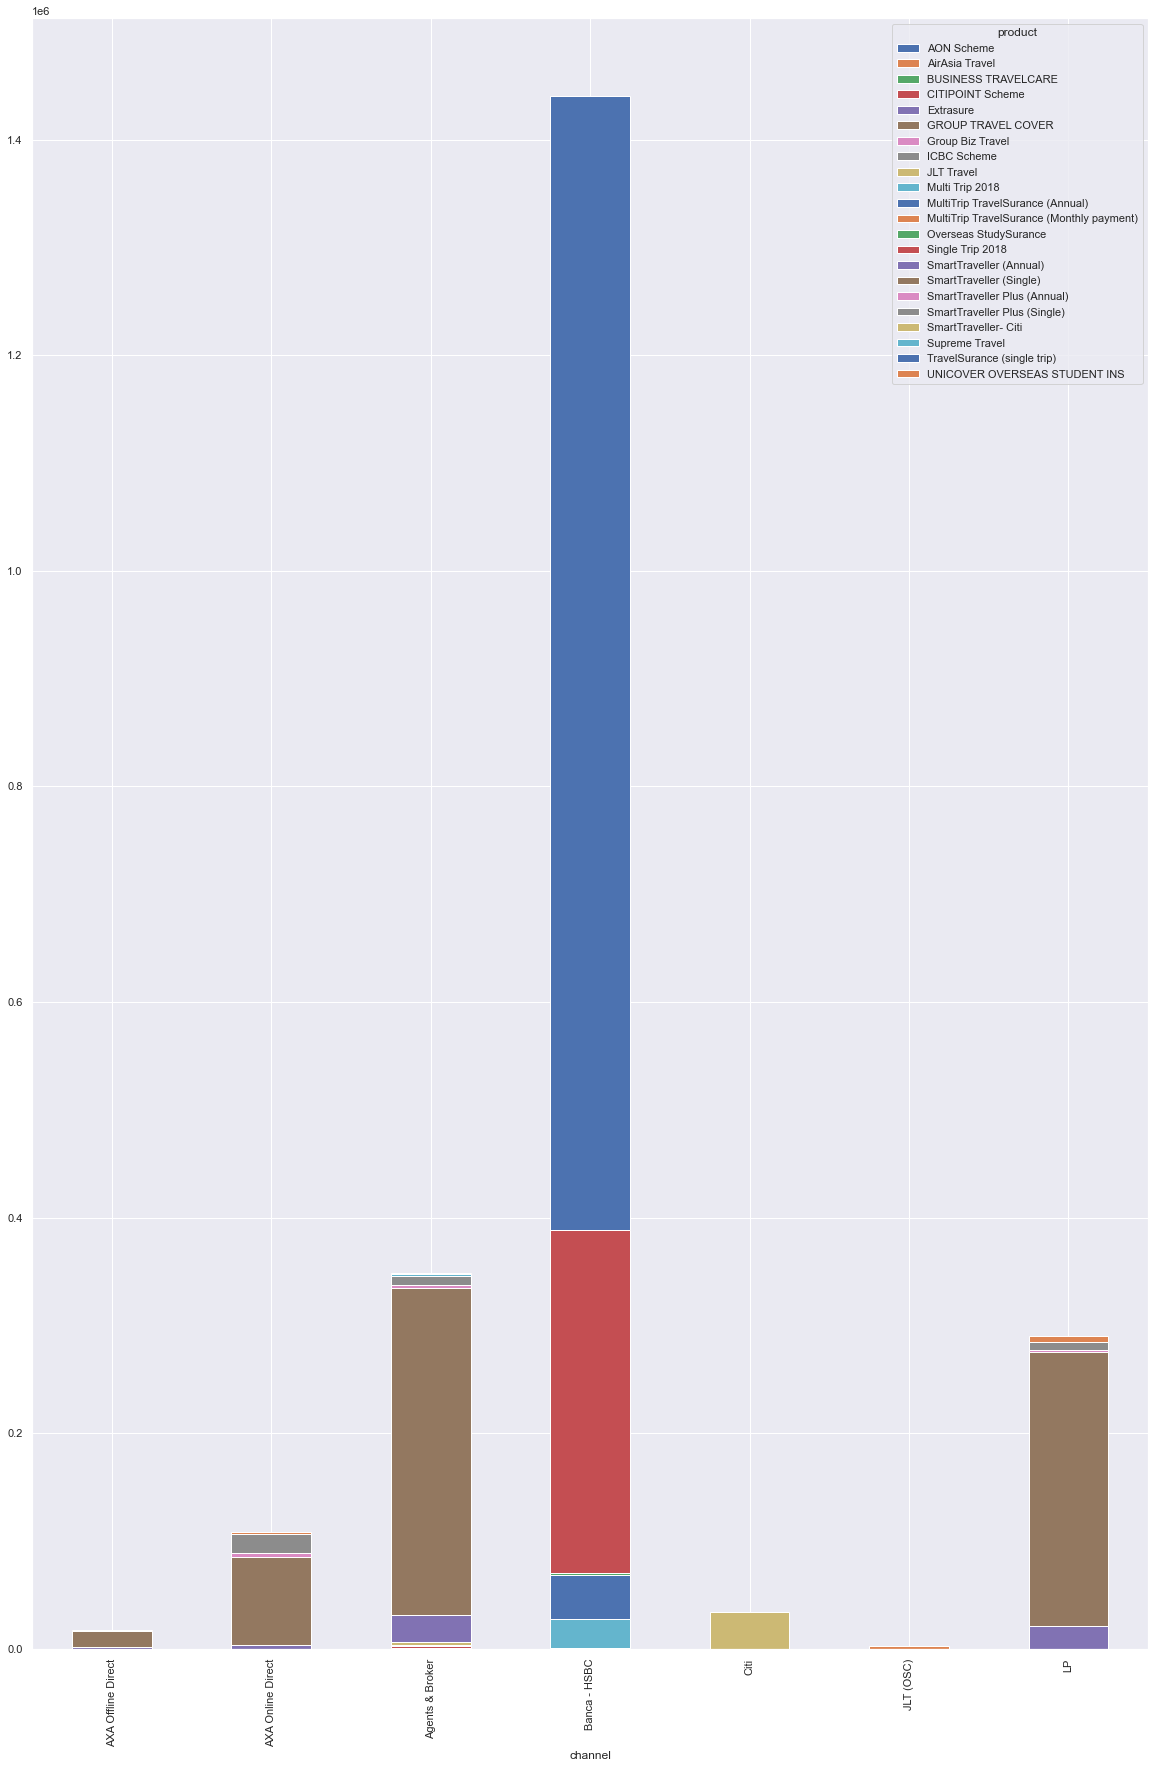

In [28]:
#plot the graph of new_df where x is channel, y is product, and the size of the dot is the value counts of product in each channel group by channel then group by products then count number of unique contrnb using plt and seaborn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
new_df.plot(kind='bar', stacked=True, figsize=(20, 30))
plt.show()


In [233]:
# value count channels
basestat_df['channel'].value_counts()

Banca - HSBC          3815431
Agents & Broker        569537
LP                     475995
AXA Online Direct      129927
Citi                    36969
AXA Offline Direct      28763
JLT (OSC)               26740
Name: channel, dtype: int64

In [11]:
basestat_df.drop_duplicates(subset='contrnb').groupby(['channel','product'])['contrnb'].nunique().sort_values(ascending=False).head(50)

channel             product                                  
Banca - HSBC        TravelSurance (single trip)                  1051718
                    Single Trip 2018                              318058
Agents & Broker     SmartTraveller (Single)                       303079
LP                  SmartTraveller (Single)                       254288
AXA Online Direct   SmartTraveller (Single)                        82370
Banca - HSBC        MultiTrip TravelSurance (Annual)               40478
Citi                SmartTraveller- Citi                           34617
Banca - HSBC        Multi Trip 2018                                27195
Agents & Broker     SmartTraveller (Annual)                        24761
LP                  SmartTraveller (Annual)                        21255
AXA Online Direct   SmartTraveller Plus (Single)                   17559
AXA Offline Direct  SmartTraveller (Single)                        15446
Agents & Broker     SmartTraveller Plus (Single)              

In [8]:
basestat_df.drop_duplicates(subset='contrnb').groupby(['channel','product'])['contrnb'].count().sort_values(ascending=False).head(50)

channel             product                                  
Banca - HSBC        TravelSurance (single trip)                  1051718
                    Single Trip 2018                              318058
Agents & Broker     SmartTraveller (Single)                       303079
LP                  SmartTraveller (Single)                       254288
AXA Online Direct   SmartTraveller (Single)                        82370
Banca - HSBC        MultiTrip TravelSurance (Annual)               40478
Citi                SmartTraveller- Citi                           34617
Banca - HSBC        Multi Trip 2018                                27195
Agents & Broker     SmartTraveller (Annual)                        24761
LP                  SmartTraveller (Annual)                        21255
AXA Online Direct   SmartTraveller Plus (Single)                   17559
AXA Offline Direct  SmartTraveller (Single)                        15446
Agents & Broker     SmartTraveller Plus (Single)              

In [9]:
basestat_df.drop_duplicates(subset='contrnb').groupby(['product','channel'])['channel'].count().sort_values(ascending=False).head(100)

product                      channel           
TravelSurance (single trip)  Banca - HSBC          1051718
Single Trip 2018             Banca - HSBC           318058
SmartTraveller (Single)      Agents & Broker        303079
                             LP                     254288
                             AXA Online Direct       82370
                                                    ...   
Extrasure                    LP                          0
GROUP TRAVEL COVER           AXA Offline Direct          0
                             AXA Online Direct           0
                             Agents & Broker             0
                             Citi                        0
Name: channel, Length: 100, dtype: int64

In [11]:
basestat_df.drop_duplicates(subset='contrnb')['product'].value_counts()

TravelSurance (single trip)                  1051718
SmartTraveller (Single)                       655183
Single Trip 2018                              318058
SmartTraveller (Annual)                        50797
MultiTrip TravelSurance (Annual)               40478
SmartTraveller- Citi                           34617
SmartTraveller Plus (Single)                   33128
Multi Trip 2018                                27195
UNICOVER OVERSEAS STUDENT INS                  11675
SmartTraveller Plus (Annual)                    8090
CITIPOINT Scheme                                2663
JLT Travel                                      2653
Overseas StudySurance                           1839
Supreme Travel                                  1434
BUSINESS TRAVELCARE                              685
MultiTrip TravelSurance (Monthly payment)        526
AON Scheme                                       419
Group Biz Travel                                 419
Extrasure                                     

In [ ]:
# plot by year, each product name and channel 

In [91]:
basestat_df[['product','duration','plan1','plan2','plan3','contrnb']]

,product,duration,plan1,plan2,plan3,contrnb
0,None,NaN,NaN,None,None,00301996
1,None,NaN,NaN,None,None,00307066
2,None,NaN,NaN,None,None,00310357
3,None,NaN,NaN,None,None,00314982
4,None,NaN,NaN,None,None,00319036
...,...,...,...,...,...,...
5086226,SmartTraveller Plus (Single),12.0,Single,Advance,Insured Only,Z1942629
5086227,SmartTraveller Plus (Single),12.0,Single,Superior,Insured Only,Z1942631
5086228,SmartTraveller (Single),8.0,Single,Specified Countries,Insured Only,Z1942637
5086229,SmartTraveller Plus (Single),12.0,Single,Advance,Insured Only,Z1942650


In [98]:
basestat_df['product'].values

array([None, None, None, ..., 'SmartTraveller (Single)',
       'SmartTraveller Plus (Single)', 'SmartTraveller Plus (Single)'],
      dtype=object)

In [102]:
basestat_df[basestat_df['product'].isna()].drop_duplicates(subset='contrnb')[['product','duration','plan1','plan2','plan3','contrnb']]

,product,duration,plan1,plan2,plan3,contrnb
0,None,NaN,NaN,None,None,00301996
1,None,NaN,NaN,None,None,00307066
2,None,NaN,NaN,None,None,00310357
3,None,NaN,NaN,None,None,00314982
4,None,NaN,NaN,None,None,00319036
...,...,...,...,...,...,...
2307672,None,NaN,NaN,None,None,86307164
2534782,None,NaN,NaN,None,None,00601774
2540997,None,NaN,NaN,None,None,24317585
3390421,None,NaN,NaN,None,None,Z1150723


In [88]:
prembase_df['trlarea'].value_counts()

1    1931070
9     783976
2     644923
C     335896
X     296828
W     245655
Z     187417
V     165313
Y      83061
D      50929
E      14578
I       5402
L       2528
B       1910
4        672
G        656
A        324
3        163
F        135
P         33
S         14
M         10
O          7
Q          1
Name: trlarea, dtype: int64

In [23]:
print("prembase_df shape:", prembase_df.shape)
print("number of policies:", prembase_df['contrnb'].nunique())
print("number of unique clients (using client no.):", prembase_df['COWNNUM'].nunique())

prembase_df shape: (4844657, 79)
number of policies: 2421762
number of unique clients (using client no.): 1499865


In [10]:
# convert column OCCDATE to datetime at prembase_df
prembase_df["OCCDATE"] = pd.to_datetime(prembase_df["OCCDATE"], format="%Y%m%d")

# assign OCCDATE_year as year of OCCDATE
prembase_df["OCCDATE_year"] = prembase_df["OCCDATE"].dt.year

In [11]:
prembase_df["CCDATE_year"] = prembase_df["CCDATE"].dt.year

In [25]:
prembase_df.value_counts("channel")

channel
Banca - HSBC          3467640
Agents & Broker        709639
LP                     450062
AXA Online Direct      118661
AXA Offline Direct      48049
Citi                    35874
JLT (OSC)               14732
dtype: int64

In [26]:
# find the unique number of contrnb, groupby channel
# number of policies per channel
prembase_df.groupby("channel")["contrnb"].nunique()

channel
AXA Offline Direct      38250
AXA Online Direct      108398
Agents & Broker        477928
Banca - HSBC          1441310
Citi                    34617
JLT (OSC)                2696
LP                     318828
Name: contrnb, dtype: int64

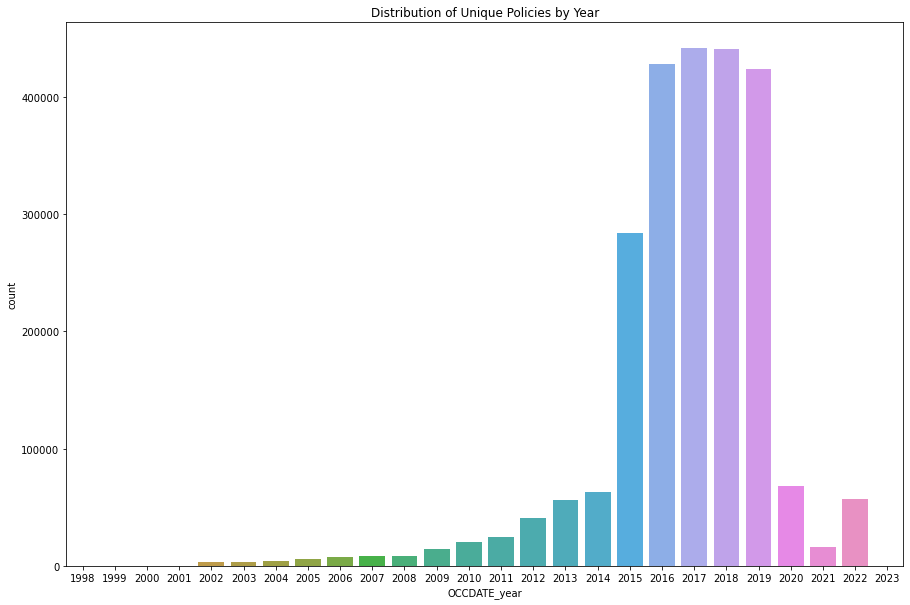

In [17]:
# plot the year distribution of each distinct contrnb at prembase_df using seaborn
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
# sns.displot(prembase_df.drop_duplicates(subset=["contrnb"])["OCCDATE_year"], kind="kde")

# Turn this into seaborn: prembase_df.drop_duplicates(subset=["contrnb"])["OCCDATE_year"].value_counts().sort_index().plot(kind="bar")
drop_d=prembase_df.drop_duplicates(subset=["contrnb"])
#plot the value count of OCCDATE_year using seaborn
sns.countplot(x="OCCDATE_year", data=drop_d)
plt.title("Distribution of Unique Policies by Year")
plt.show()

# Add title to the plot using plt and seaborn 
# title name is "Distribution of Unique Policies by Year"


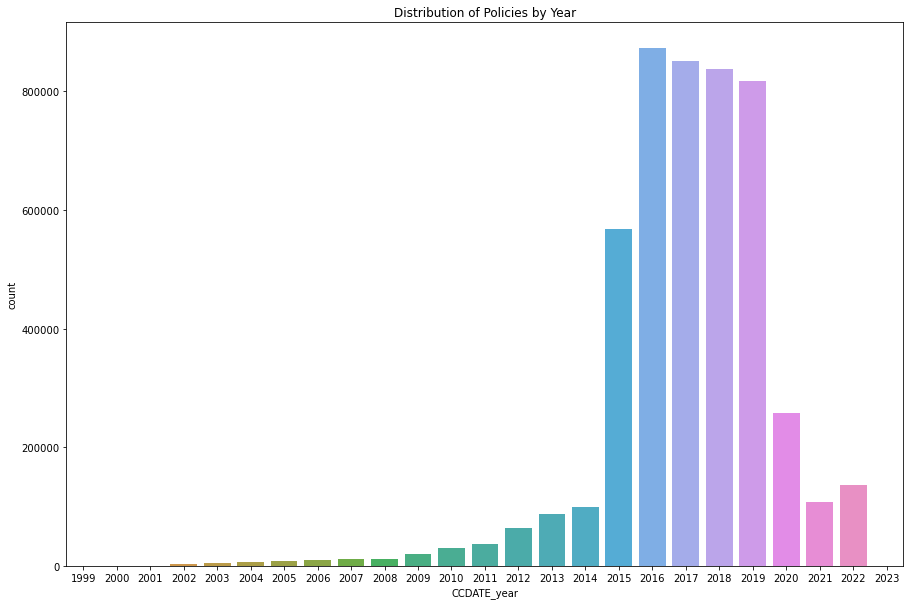

In [18]:
# plot the year distribution of each distinct contrnb at prembase_df using seaborn
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
# sns.displot(prembase_df.drop_duplicates(subset=["contrnb"])["CCDATE_year"], kind="kde")

# Turn this into seaborn: prembase_df.drop_duplicates(subset=["contrnb"])["CCDATE_year"].value_counts().sort_index().plot(kind="bar")

df=prembase_df
#plot the value count of CCDATE_year using seaborn
sns.countplot(x="CCDATE_year", data=df)
# Add title to the plot using plt and seaborn 
# title name is "Distribution of Policies by Year"
plt.title("Distribution of Policies by Year")
plt.show()

In [28]:
print("before filter by 19970101:", prembase_df.shape)

# keep prembase_df with OCCDATE >= 2002-01-01
prembase_df = prembase_df[prembase_df["OCCDATE"] >= pd.to_datetime(20020101, format="%Y%m%d")]

print("after filter by 20020101:", prembase_df.shape)

before filter by 19970101: (4844657, 80)
after filter by 20020101: (4787992, 80)


In [3]:
# read parquet CLIENT_DATA_MAPPING_FILE
#TOO big wait for remote desktop
client_data_df = pd.read_parquet(CLIENT_DATA_MAPPING_FILE)

NameError: name 'CLIENT_DATA_MAPPING_FILE' is not defined

# merge with client data

In [30]:
print("prembase_df size before merge:", prembase_df.shape)
#COWNNUM=client number 
# left join prembase_df with client_data_df, using column CLNTNUM from client_data_df and column COWNNUM from prembase_df as key
prembase_w_client_df = prembase_df.merge(client_data_df, left_on="COWNNUM", right_on="CLNTNUM", how="left")

print("prembase_df size after merge:", prembase_w_client_df.shape)

prembase_df size before merge: (4787992, 80)
prembase_df size after merge: (4787992, 91)


In [31]:
# count the unique number of modified_SECUITYNO, groupby channel
# Number of unique clients
prembase_w_client_df.groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct     12814
AXA Online Direct      62919
Agents & Broker       197807
Banca - HSBC          394641
Citi                   18333
JLT (OSC)               1894
LP                    130378
Name: modified_SECUITYNO, dtype: int64

In [32]:
prembase_2002_df = prembase_w_client_df[prembase_w_client_df["OCCDATE"] >= pd.to_datetime("2002-01-01", format="%Y-%m-%d")]

In [33]:
# count the unique number of modified_SECUITYNO, groupby channel
prembase_2002_df.groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct     12814
AXA Online Direct      62919
Agents & Broker       197807
Banca - HSBC          394641
Citi                   18333
JLT (OSC)               1894
LP                    130378
Name: modified_SECUITYNO, dtype: int64

### check overlap GI & L&H clients

In [34]:
#### import L&H app data
health_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "HEALTH_APPLICATION_19970101.parquet"))
health_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "HEALTH_APPLICATION_HISTORIC_19970101.parquet"))
life_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "LIFE_APPLICATION_19970101.parquet"))
life_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "LIFE_APPLICATION_HISTORIC_19970101.parquet"))
dis_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "DISABLE_APPLICATION_19970101.parquet"))
dis_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "DISABLE_APPLICATION_HISTORIC_19970101.parquet"))
rider_app_df = pd.read_parquet(os.path.join(VER_1122_DIR, "RIDER_APPLICATION_19970101.parquet"))
rider_app_his_df = pd.read_parquet(os.path.join(VER_1122_DIR, "RIDER_APPLICATION_HISTORIC_19970101.parquet"))
#### import L&H policy data
health_pol_df = pd.read_parquet(os.path.join(VER_1212_DIR, "HEALTH_POLICY_19970101.parquet"))
life_pol_df = pd.read_parquet(os.path.join(VER_1212_DIR, "LIFE_POLICY_19970101.parquet"))
dis_pol_df = pd.read_parquet(os.path.join(VER_1212_DIR, "DISABLE_POLICY_19970101.parquet"))

# concat base app 19970101

all_app_wo_rider_df = pd.concat([health_app_df, health_app_his_df, life_app_df, life_app_his_df, dis_app_df, dis_app_his_df], axis=0)
print("all_app_wo_rider_df size before drop duplicates:", all_app_wo_rider_df.shape)

# check the number of duplicated POLICY_NO at all_app_wo_rider_df
print("number of duplicated PNO:", all_app_wo_rider_df["POLICY_NO"].duplicated().sum())

# drop duplicates of POLICY_NO at all_app_wo_rider_df
all_app_wo_rider_df.drop_duplicates("POLICY_NO", inplace=True)
print("all_app_wo_rider_df size after drop duplicates:", all_app_wo_rider_df.shape)

# convert SUBMIT_DATE to datetime
all_app_wo_rider_df["SUBMIT_DATE"] = pd.to_datetime(all_app_wo_rider_df["SUBMIT_DATE"], format="%Y%m%d")

print("before filter by 2002-01-01:", all_app_wo_rider_df.shape)

# keep all_app_wo_rider_df with "SUBMIT_DATE" >= "20020101"
all_app_wo_rider_df = all_app_wo_rider_df[all_app_wo_rider_df["SUBMIT_DATE"] >= pd.to_datetime(20020101, format="%Y%m%d")]

print("after filter by 2002-01-01:", all_app_wo_rider_df.shape)

# concat health_pol_df, life_pol_df, dis_pol_df
all_pol_df = pd.concat([health_pol_df, life_pol_df, dis_pol_df], axis=0)
print(all_pol_df.shape)

# check the number of duplicated POLICY_NO at all_pol_df
all_pol_df["POLICY_NO"].duplicated().sum()

print("all_app_wo_rider_df size before merge:", all_app_wo_rider_df.shape)

# merge all_app_wo_rider_df with all_pol_df[["POLICY_NO", "STATUS_CODE"]], on POLICY_NO
all_app_wo_rider_df = all_app_wo_rider_df.merge(all_pol_df[["POLICY_NO", "STATUS_CODE"]], on="POLICY_NO", how="left")

print("all_app_wo_rider_df size after merge with all_pol_df:", all_app_wo_rider_df.shape)

# assign a new column "IS_INFORCE_FLAG", 1 if STATUS_CODE isin INFORCE_STATUS_LST, 0 otherwise, use np.where
all_app_wo_rider_df["IS_INFORCE_FLAG"] = np.where(all_app_wo_rider_df["STATUS_CODE"].isin(INFORCE_STATUS_LST), 1, 0)
all_app_wo_rider_df["IS_INFORCE_FLAG"].value_counts()

# extract base plan type from plan code

all_app_wo_rider_df["BASE_PLAN_TYPE"] = find_plan_type(all_app_wo_rider_df["PLAN_CODE"])
all_app_wo_rider_df["BASE_PLAN_TYPE"].value_counts()

del health_app_df
del health_app_his_df
del life_app_df
del life_app_his_df
del dis_app_df
del dis_app_his_df
del health_pol_df
del life_pol_df
del dis_pol_df

gc.collect()

all_app_wo_rider_df.shape

# concat rider_app

all_rider_app_df = pd.concat([rider_app_df, rider_app_his_df], axis=0)
all_rider_app_df.shape

# weird distribution as all_rider_app is not filtered by SUBMIT_DATE

all_rider_app_df["RIDER_PLAN_TYPE"] = find_plan_type(all_rider_app_df["PLAN_CODE"])
all_rider_app_df["RIDER_PLAN_TYPE"].value_counts()

# make flag for WGP plan

all_rider_app_df["IS_WGP_RIDER"] = np.where(all_rider_app_df["PLAN_CODE"].isin(WGP_LST), 1, 0)

all_app_w_rider_df=all_app_wo_rider_df

# free memory

del rider_app_df
del rider_app_his_df
del all_pol_df
del all_app_wo_rider_df
del all_rider_app_df
# del one_hot_all_rider_app_df
# del one_hot_summary_all_rider_app_df

gc.collect()

# strip to avoid space in id columns
all_app_w_rider_df["OWNER_HKID"] = all_app_w_rider_df["OWNER_HKID"].str.strip()
all_app_w_rider_df["ID_NO"] = all_app_w_rider_df["ID_NO"].str.strip()

# assign a new column id, use OWNER_HKID if not equals to "", otherwise use ID_NO
all_app_w_rider_df["owner_id"] = np.where(all_app_w_rider_df["OWNER_HKID"]!="", all_app_w_rider_df["OWNER_HKID"], all_app_w_rider_df["ID_NO"])
(all_app_w_rider_df["owner_id"] == "").sum()

# assign a new column modified_owner_id, which is the same as owner_id, except that all non-alphanumeric characters are removed
all_app_w_rider_df["modified_owner_id"] = all_app_w_rider_df["owner_id"].str.replace(r'\W+', '')

all_app_wo_rider_df size before drop duplicates: (2454138, 85)
number of duplicated PNO: 8
all_app_wo_rider_df size after drop duplicates: (2454130, 85)
before filter by 2002-01-01: (2454130, 85)
after filter by 2002-01-01: (1921779, 85)
(2388568, 9)
all_app_wo_rider_df size before merge: (1921779, 85)
all_app_wo_rider_df size after merge with all_pol_df: (1921779, 86)


C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_5636/1066179204.py:111: FutureWarning: The default value of regex will change from True to False in a future version.
  all_app_w_rider_df["modified_owner_id"] = all_app_w_rider_df["owner_id"].str.replace(r'\W+', '')


In [35]:
prem_w_medical_df = pd.merge(prembase_2002_df, all_app_w_rider_df, how="left", left_on="modified_SECUITYNO", right_on="modified_owner_id")
#MERGE HERE

In [36]:
prem_w_medical_df['bought_medic_flag']=np.where(prem_w_medical_df["modified_owner_id"].isna(), 0, 1)

# Read prem_w_medical_df

In [33]:
# readprem_w_medical_df
prem_w_medical_df=pd.read_parquet(r"Z:\13.Data Science\Projects\2022_GI_Xsell\Code\notebooks\prem_w_medical_df.parquet")

In [38]:
prem_w_medical_df[['channel']]

,channel
0,Banca - HSBC
1,Banca - HSBC
2,Banca - HSBC
3,Banca - HSBC
4,Banca - HSBC
...,...
6676747,Agents & Broker
6676748,Agents & Broker
6676749,Agents & Broker
6676750,AXA Online Direct


In [40]:
#sort only channel = HSBC
hsbc=prem_w_medical_df[prem_w_medical_df['channel']=='Banca - HSBC']
#check how many unique contrnb has modified_SECUITYNO
hsbc.groupby('contrnb')['modified_SECUITYNO'].nunique().sort_values(ascending=False)

MemoryError: Unable to allocate 1.70 GiB for an array with shape (59, 3872986) and data type float64

In [ ]:
# plot a bubble chart
# where x-axis is'age', y-axis is number of unique "modified_SECUITYNO", and the size of bubble is average number count of 'contrnb'.
# df is prem_w_medical_df

# plot a bubble chart






In [28]:
list(prem_w_medical_df.columns)

['contrnb',
 'CCDATE',
 'age',
 'RSKNO',
 'TRANNO',
 'DTEEFF',
 'gwp',
 'commis',
 'disc',
 'BATCACTYR',
 'BATCACTMN',
 'CRATE',
 'TRANDATE',
 'trans_code',
 'CNTTYPE',
 'OCCDATE',
 'CRDATE',
 'REPNUM',
 'COWNNUM',
 'AGNTNUM',
 'CNTBRANCH',
 'autorenew',
 'line',
 'ZDMIND',
 'ACSART',
 'bulk',
 'bulk_name',
 'nbrn',
 'tranat',
 'nwp',
 'commis_n',
 'ri_inward',
 'JACKET',
 'product',
 'bulk_name1',
 'CLTTYPE_x',
 'CLTSEX_x',
 'CLTDOB_x',
 'MARRYD_x',
 'NATLTY_x',
 'RSKTYP',
 'ldteter',
 'risk_des',
 'INSURED',
 'TOTSIL',
 'ZPLNCD',
 'ZPLANCDE',
 'trlarea',
 'znolive',
 'zcmccard_banca',
 'plan1',
 'lastcrdate',
 'cancdate',
 'cancelled',
 'dteeff_term',
 'duration',
 'lastznolive',
 'plan2',
 'plan3',
 'ChinaCard',
 'EnhancedPA',
 'duration_grp',
 'NBRN1',
 'producer',
 'rmisagent',
 'rmiscode',
 'channel',
 'lifeagent',
 'product2',
 'gap_trandate_ccdate',
 'gap_trandate_ccdate_gp',
 'znolive_gp',
 'age_gp',
 'loyalty',
 'loyalty_cat',
 'insage_smu',
 'inssex_smu',
 'insage_smu_gp',
 

In [14]:
ccountPercentage=prem_w_medical_df[['modified_SECUITYNO','bought_medic_flag']]

In [15]:
ccountPercentage.head()

,modified_SECUITYNO,bought_medic_flag
0,D573231,0
1,D573231,0
2,D573231,0
3,D573231,0
4,D573231,0


In [16]:
ccountPercentage

,modified_SECUITYNO,bought_medic_flag
0,D573231,0
1,D573231,0
2,D573231,0
3,D573231,0
4,D573231,0
...,...,...
6676747,1434619,0
6676748,A123456,0
6676749,A123456,0
6676750,Z660017,0


In [17]:
ccountPercentage['modified_SECUITYNO'].nunique()

758386

In [18]:
countPercentageDropDuplicates=ccountPercentage.drop_duplicates(['modified_SECUITYNO','bought_medic_flag'],keep= 'last')

In [19]:
countPercentageDropDuplicates

,modified_SECUITYNO,bought_medic_flag
13,D573231,0
35,M009061,0
49,R629644,0
65,C507071,0
77,R827089,0
...,...,...
6676745,D241066,0
6676746,K957229,1
6676747,1434619,0
6676749,A123456,0


In [20]:
countPercentageDropDuplicates['bought_medic_flag'].value_counts()

0    649162
1    109225
Name: bought_medic_flag, dtype: int64

In [21]:
countPercentageDropDuplicates['bought_medic_flag'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

0    85.6%
1    14.4%
Name: bought_medic_flag, dtype: object

# Get clients_wo_medical

In [21]:
clients_wo_medical=prem_w_medical_df[prem_w_medical_df["bought_medic_flag"]==0]

In [23]:
#latest occdate - first occdate
clients_wo_medical.groupby("OCCDATE").agg({"CCDATE": [min, max]})

CCDATE            
                   min         max
OCCDATE                           
2002-01-01  20020101.0  20020101.0
2002-01-03  20150703.0  20170703.0
2002-01-07  20150707.0  20221007.0
2002-01-15  20150615.0  20180115.0
2002-01-16  20150616.0  20221016.0
...                ...         ...
2023-01-18  20230118.0  20230118.0
2023-01-19  20230119.0  20230119.0
2023-01-20  20230120.0  20230120.0
2023-01-21  20230121.0  20230121.0
2023-01-23  20230123.0  20230123.0

[7633 rows x 2 columns]

# Create new col catagorized by TRAVEL_SINGLE_MULTI_TRIP_DICT


In [50]:
clients_wo_medical['plan1'].value_counts()

Single                 3337178
Annual                  705663
Annual/Over 30 Days       1080
Unknown                     41
Name: plan1, dtype: int64

In [51]:
TRAVEL_SINGLE_MULTI_TRIP_DICT = {
'Single': 'Single',
'Annual': 'Annual',
'Annual/Over 30 Days': 'Annual',
}

In [52]:
TRAVEL_SINGLE_MULTI_TRIP_DICT

{'Single': 'Single', 'Annual': 'Annual', 'Annual/Over 30 Days': 'Annual'}

In [53]:
#create a new colume "TRAVEL_SINGLE_MULTI_TRIP" in clients_wo_medical based on 'product' and TRAVEL_SINGLE_MULTI_TRIP_DICT.
clients_wo_medical['TRAVEL_SINGLE_MULTI_TRIP']=clients_wo_medical['plan1'].map(TRAVEL_SINGLE_MULTI_TRIP_DICT)

In [54]:
#check the result
clients_wo_medical['TRAVEL_SINGLE_MULTI_TRIP'].value_counts()


Single    3337178
Annual     706743
Name: TRAVEL_SINGLE_MULTI_TRIP, dtype: int64

In [55]:
# rename column 'TRAVEL_SINGLE_MULTI_TRIP' to 'TRAVEL_SINGLE_ANNUAL_TRIP'
clients_wo_medical.rename(columns={'TRAVEL_SINGLE_MULTI_TRIP': 'TRAVEL_SINGLE_ANNUAL_TRIP'}, inplace=True)

# DF in desired time range

In [124]:
TIME_RANGE_MIN = 20020101 
TIME_RANGE_MAX = 20181231
#get OCCDATE >= 20200101 and OCCDATE <= 20221031
DF_in_desired_timerage=clients_wo_medical[(clients_wo_medical["OCCDATE"]>= pd.to_datetime(TIME_RANGE_MIN, format="%Y%m%d")) & (clients_wo_medical["OCCDATE"]<= pd.to_datetime(TIME_RANGE_MAX, format="%Y%m%d"))]
DF_in_desired_timerage['OCCDATE'].sort_values()
DF_in_desired_timerage['modified_SECUITYNO'].value_counts()
DF_in_desired_timerage[DF_in_desired_timerage['modified_SECUITYNO']=='C640656']
DF_in_desired_timerage.groupby(['modified_SECUITYNO'])["contrnb"].nunique().sort_values().tail(20)
#each person have how many unique order in last 3 month
DUMMY_ID=['unknown','A123456','F123456']
# show column 'modified_SECUITYNO' and 'age' only, while filter out rows where 'modified_SECUITYNO' is in DUMMY_ID
DF_in_desired_timerage[DF_in_desired_timerage['modified_SECUITYNO'].isin(DUMMY_ID)][['modified_SECUITYNO','age']].value_counts()
DF_in_desired_timerage.groupby(['modified_SECUITYNO'])["contrnb"].nunique().sort_values()
z = DF_in_desired_timerage.groupby(['modified_SECUITYNO'])["contrnb"].nunique().sort_values()
z1=z.to_dict()
len(z1)
DF_in_desired_timerageID=DF_in_desired_timerage[['modified_SECUITYNO','TRAVEL_SINGLE_ANNUAL_TRIP','contrnb']].copy()
DF_in_desired_timerageID
#group by modified_SECUITYNO and TRAVEL_SINGLE_ANNUAL_TRIP and count the number of unique contrnb
DF_in_desired_timerageID.groupby(['modified_SECUITYNO','TRAVEL_SINGLE_ANNUAL_TRIP'])["contrnb"].nunique().sort_values()
#group by modified_SECUITYNO and TRAVEL_SINGLE_ANNUAL_TRIP and count the number of unique contrnb then output the result as a new df
DF_in_desired_timerageID.groupby(['modified_SECUITYNO','TRAVEL_SINGLE_ANNUAL_TRIP'])["contrnb"].nunique().sort_values().to_frame().reset_index()

DF_in_desired_timerageID1=DF_in_desired_timerageID.groupby(['modified_SECUITYNO','TRAVEL_SINGLE_ANNUAL_TRIP'])["contrnb"].nunique().sort_values().to_frame().reset_index()

# rename contrnb to Number_unique_contrnb in DF_in_desired_timerageID1
DF_in_desired_timerageID1.rename(columns={'contrnb': 'Number_unique_contrnb'}, inplace=True)
DF_in_desired_timerageID1
# drop rows where 'modified_SECUITYNO' is in DUMMY_ID in DF_in_desired_timerageID1 
DF_in_desired_timerageID1=DF_in_desired_timerageID1[~DF_in_desired_timerageID1['modified_SECUITYNO'].isin(DUMMY_ID)]

DF_in_desired_timerageID1['Number_unique_contrnb'].value_counts().sort_values()
#368 ppl have bought 1 order in last 3 month
#1 ppl have bought 3 order in 2020-20221001 
# Number of unique modified_SECUITYNO in DF_in_desired_timerageID1 group by TRAVEL_SINGLE_ANNUAL_TRIP
DF_in_desired_timerageID1.groupby(['TRAVEL_SINGLE_ANNUAL_TRIP'])["modified_SECUITYNO"].nunique().sort_values()
# Get rows where 'Number_unique_contrnb' is >= 1 in DF_in_desired_timerageID1
Atleast1times=DF_in_desired_timerageID1[DF_in_desired_timerageID1['Number_unique_contrnb']>=1]
# Number of unique modified_SECUITYNO in Atleast1times group by TRAVEL_SINGLE_ANNUAL_TRIP
Atleast1times.groupby(['TRAVEL_SINGLE_ANNUAL_TRIP'])["modified_SECUITYNO"].nunique().sort_values()

for i in range(4):
    AtLeatThisTimes=i
    print(f'AtLeatThisTimes={AtLeatThisTimes}')
    Atleasttimes=DF_in_desired_timerageID1[DF_in_desired_timerageID1['Number_unique_contrnb']>=AtLeatThisTimes]
    print(Atleasttimes.groupby(['TRAVEL_SINGLE_ANNUAL_TRIP'])["modified_SECUITYNO"].nunique().sort_values())
    # AtLeatThisTimes=AtLeatThisTimes+1

AtLeatThisTimes=0
TRAVEL_SINGLE_ANNUAL_TRIP
Annual     59145
Single    507919
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=1
TRAVEL_SINGLE_ANNUAL_TRIP
Annual     59145
Single    507919
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=2
TRAVEL_SINGLE_ANNUAL_TRIP
Annual      9490
Single    245968
Name: modified_SECUITYNO, dtype: int64
AtLeatThisTimes=3
TRAVEL_SINGLE_ANNUAL_TRIP
Annual      2284
Single    159095
Name: modified_SECUITYNO, dtype: int64


In [103]:
# count how many rows where Number_of_Policy >=3
(DF_in_desired_timerageID1['Number_unique_contrnb'] == 3).sum()

7

In [363]:
# show all rows where modified_SECUITYNO == 'Y548690' in DF_in_desired_timerage then sort by OCCDATE
DF_in_desired_timerage[DF_in_desired_timerage['modified_SECUITYNO']=='0590534'].sort_values(by=['OCCDATE'])


,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE_x,CLTSEX_x,CLTDOB_x,MARRYD_x,NATLTY_x,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,OCCDATE_year,CLNTNUM,VALIDFLAG,CLTTYPE_y,SECUITYNO,CLTSEX_y,OCCPCODE,CLTDOB_y,START_DATE,MARRYD_y,NATLTY_y,modified_SECUITYNO,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,owner_id,modified_owner_id,bought_medic_flag
6584328,Z1370348,2022-04-18,9999.0,1.0,1.0,20220418.0,416.0,135.20,0.0,2022.0,4.0,1.0,2022-04-15,T405,STJ,2022-04-18,20220430.0,None,1692570,02967,10,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,411.04960,135.20,N,STB1219A,SmartTraveller Plus (Single),N,C,NaN,NaN,NaN,None,ATP,99999999.0,PA,S0,1200000.0,None,O4,9,1.0,NaN,Single,20220430.0,NaN,0.0,99999999.0,13.0,1.0,Advance,Insured Only,N,N,6. 11-14 Days,NWBS,Jebsen Insurance Brokers Ltd,JEBSEN INSURANCE BROKERS LTD,JIBL,Agents & Broker,0.0,SmartTraveller Plus,3.0,2. 1 to 5 days,1. 1 person,9. unknown,-0.0,Single,NaN,NaN,NaN,0. No Discount,2022,1692570,1,C,05905346,None,None,99999999.0,20220415.0,None,None,0590534,NaN,NaN,None,NaT,NaN,NaN,NaN,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,None,None,None,NaN,None,None,None,0
6584860,Z1370685,2022-04-21,9999.0,1.0,1.0,20220421.0,645.0,209.63,0.0,2022.0,4.0,1.0,2022-04-21,T405,STJ,2022-04-21,20220529.0,None,1693398,02967,10,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,637.32450,209.63,N,STB1219A,SmartTraveller Plus (Single),N,C,NaN,NaN,NaN,None,ATP,99999999.0,PA,S0,500000.0,None,M4,9,1.0,NaN,Single,20220529.0,NaN,0.0,99999999.0,39.0,1.0,Basic,Insured Only,N,N,8. 31-60 Days,NWBS,Jebsen Insurance Brokers Ltd,JEBSEN INSURANCE BROKERS LTD,JIBL,Agents & Broker,0.0,SmartTraveller Plus,0.0,1. 0 days or le

In [32]:
DF_in_desired_timerage[DF_in_desired_timerage['age']!=100]['age'].value_counts()

41.0    226
30.0    181
31.0    179
33.0    177
57.0    175
       ... 
88.0      2
81.0      2
83.0      1
85.0      1
89.0      1
Name: age, Length: 72, dtype: int64

In [33]:
DF_in_desired_timerage['age'].value_counts() 

41.0    226
30.0    181
31.0    179
33.0    177
57.0    175
       ... 
88.0      2
81.0      2
83.0      1
85.0      1
89.0      1
Name: age, Length: 72, dtype: int64

<AxesSubplot:>

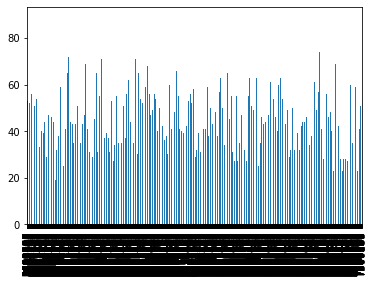

In [67]:
DF_in_desired_timerage[ ~(DF_in_desired_timerage['age'] == 9999) ]['age'].plot(kind="bar")

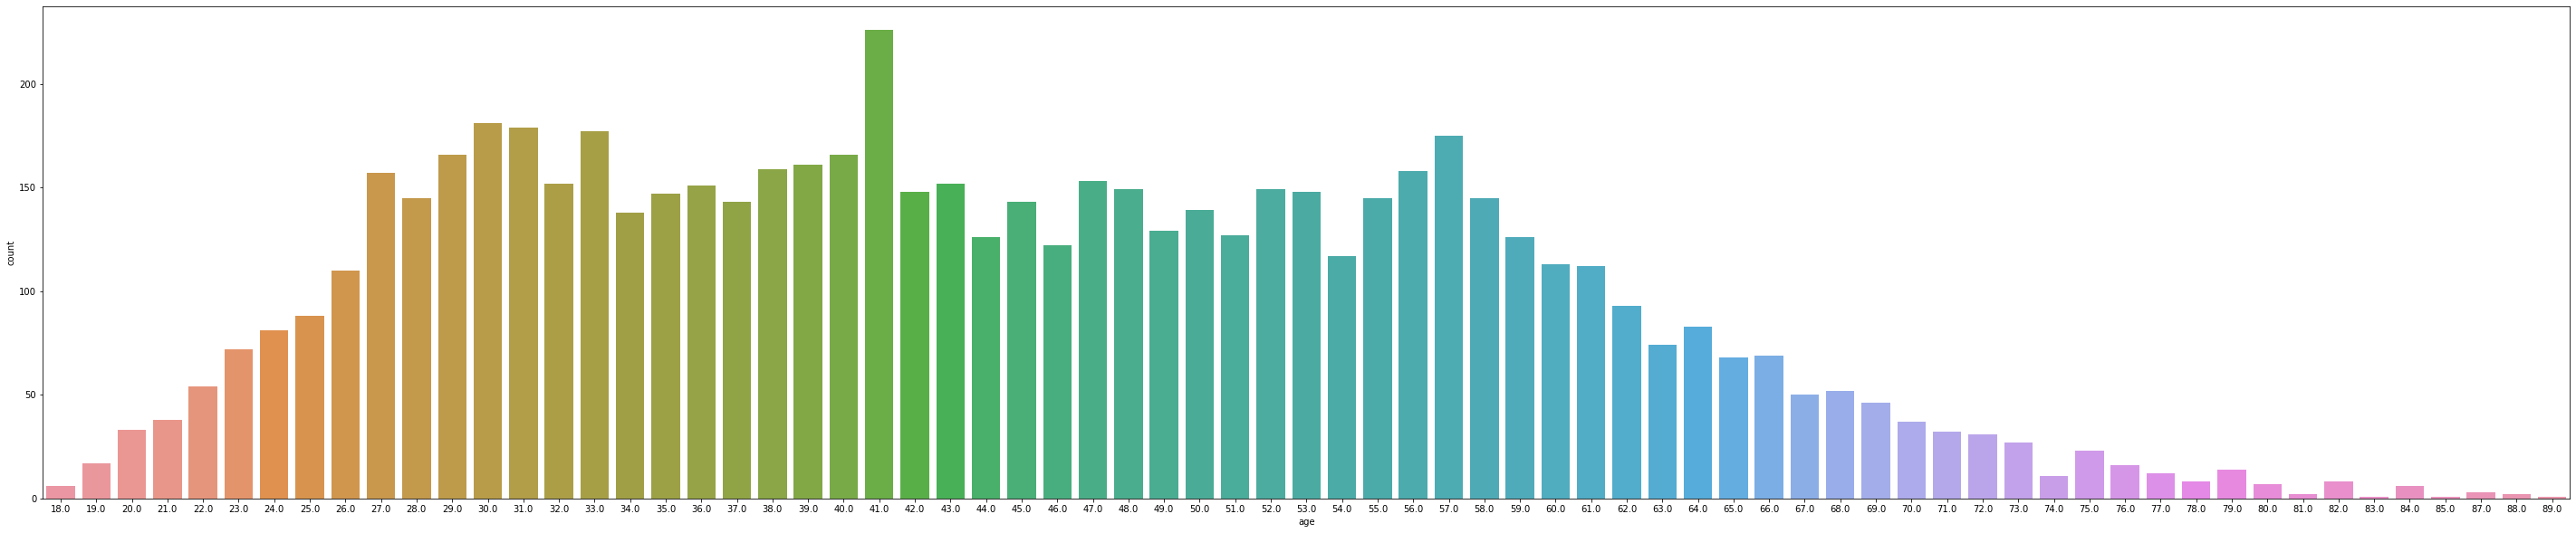

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(50,10))
df=DF_in_desired_timerage[ ~(DF_in_desired_timerage['age'] == 9999) ]
sns.countplot(x='age',data =df)
plt.show()


In [69]:
age=prem_w_medical_df.groupby(['modified_SECUITYNO'])["age"].nunique().sort_values()
age

modified_SECUITYNO
            1
K408335     1
Y571836     1
Y571850     1
K408306     1
           ..
C402056    21
P068194    21
E060346    21
A123456    23
unknown    73
Name: age, Length: 758386, dtype: int64

In [70]:
clients_wo_medical.head(10)

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE_x,CLTSEX_x,CLTDOB_x,MARRYD_x,NATLTY_x,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,OCCDATE_year,CLNTNUM,VALIDFLAG,CLTTYPE_y,SECUITYNO,CLTSEX_y,OCCPCODE,CLTDOB_y,START_DATE,MARRYD_y,NATLTY_y,modified_SECUITYNO,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,owner_id,modified_owner_id,bought_medic_flag
0,00300028,20151213.0,50.0,1.0,2.0,20151213.0,423.9,127.17,0.0,2015.0,12.0,1.0,2015-12-05,T413,STX,2011-12-13,20161212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,417.75345,127.17,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATH,99999999.0,PA,NaN,1000000.0,C,C2,2,1.0,N,Annual,20161212.0,NaN,0.0,99999999.0,366.0,1.0,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,8.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,4.0,4,NaN,NaN,NaN,0. No Discount,2011,N5017122,1,P,D573231(0),M,UNKN,19651212.0,99999999.0,M,None,D573231,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,00300028,20151213.0,50.0,2.0,2.0,20151213.0,2402.1,720.63,0.0,2015.0,12.0,1.0,2015-12-05,T413,STX,2011-12-13,20161212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,2367.26955,720.63,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATM,99999999.0,Miscellaneous,NaN,1000000.0,C,C2,2,NaN,N,Annual,20161212.0,NaN,0.0,99999999.0,0.0,NaN,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,8.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,4.0,4,NaN,NaN,NaN,0. No Discount,2011,N5017122,1,P,D573231(0),M,UNKN,19651212.0,99999999.0,M,None,D573231,NaN,NaN,NaN,NaT,N

In [87]:
clients_wo_medical.columns

Index(['contrnb', 'CCDATE', 'age', 'RSKNO', 'TRANNO', 'DTEEFF', 'gwp',
       'commis', 'disc', 'BATCACTYR',
       ...
       'INITIAL_LUMP_SUM_PREMIUM', 'LUMP_SUM_PREMIUM', 'UN_LANGUAGE_FLAG',
       'RECEIVE_SMS_FLAG', 'STATUS_CODE', 'IS_INFORCE_FLAG', 'BASE_PLAN_TYPE',
       'owner_id', 'modified_owner_id', 'bought_medic_flag'],
      dtype='object', length=182)

In [88]:
clients_wo_medical

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE_x,CLTSEX_x,CLTDOB_x,MARRYD_x,NATLTY_x,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,OCCDATE_year,CLNTNUM,VALIDFLAG,CLTTYPE_y,SECUITYNO,CLTSEX_y,OCCPCODE,CLTDOB_y,START_DATE,MARRYD_y,NATLTY_y,modified_SECUITYNO,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,owner_id,modified_owner_id,bought_medic_flag
0,00300028,20151213.0,50.0,1.0,2.0,20151213.0,423.9,127.17,0.0,2015.0,12.0,1.0,2015-12-05,T413,STX,2011-12-13,20161212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,417.75345,127.17,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATH,99999999.0,PA,NaN,1000000.0,C,C2,2,1.0,N,Annual,20161212.0,NaN,0.0,99999999.0,366.0,1.0,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,8.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,4.0,4,NaN,NaN,NaN,0. No Discount,2011,N5017122,1,P,D573231(0),M,UNKN,19651212.0,99999999.0,M,None,D573231,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,00300028,20151213.0,50.0,2.0,2.0,20151213.0,2402.1,720.63,0.0,2015.0,12.0,1.0,2015-12-05,T413,STX,2011-12-13,20161212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,2367.26955,720.63,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATM,99999999.0,Miscellaneous,NaN,1000000.0,C,C2,2,NaN,N,Annual,20161212.0,NaN,0.0,99999999.0,0.0,NaN,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,8.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,4.0,4,NaN,NaN,NaN,0. No Discount,2011,N5017122,1,P,D573231(0),M,UNKN,19651212.0,99999999.0,M,None,D573231,NaN,NaN,NaN,NaT,N

In [89]:
clients_wo_medical[['CLTSEX_y', 'CLTSEX_x']]

,CLTSEX_y,CLTSEX_x
0,M,M
1,M,M
2,M,M
3,M,M
4,M,M
...,...,...
7300187,NaN,M
7300188,None,NaN
7300190,None,NaN
7300199,M,M


# Marriage Status

In [137]:
clients_wo_medical.sample(50)

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE_x,CLTSEX_x,CLTDOB_x,MARRYD_x,NATLTY_x,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,OCCDATE_year,CLNTNUM,VALIDFLAG,CLTTYPE_y,SECUITYNO,CLTSEX_y,OCCPCODE,CLTDOB_y,START_DATE,MARRYD_y,NATLTY_y,modified_SECUITYNO,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,owner_id,modified_owner_id,bought_medic_flag
1534068,24997024,2022-04-11,41.0,1.0,13.0,20220411.0,-283.80,-85.14,0.00,2022.0,7.0,1.0,2022-07-25,T454,STX,2017-04-11,20230410.0,None,2460232,E03022,20,0.0,27 - Travel Insurance,N,AXA,N,N,RN,CANC,-280.422780,-85.14,N,BSTX0116,MultiTrip TravelSurance (Annual),N,P,M,19800826.0,NaN,HK,ATH,99999999.0,PA,NaN,1000000.0,I,I2,2,1.0,N,Annual,20230410.0,20220411.0,1.0,NaN,NaN,1.0,Area 2,Self Only,N,NA,Annual,RNWL,HSBC - Dummy,082(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,9.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,5.0,5+,NaN,NaN,NaN,0. No Discount,2017,2460232,1,P,M390950(1),M,None,19800826.0,20170411.0,None,HK,M390950,NaN,NaN,None,NaT,NaN,NaN,NaN,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,None,None,None,NaN,None,None,None,0
2387092,25425158,2018-06-02,68.0,2.0,1.0,20180602.0,1040.40,312.12,115.60,2018.0,6.0,1.0,2018-05-31,T405,STR,2018-06-02,20180630.0,None,2675756,E04550,20,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,1032.076800,312.12,N,BSTR1017,TravelSurance (single trip),N,P,NaN,19500505.0,NaN,None,ATM,99999999.0,Miscellaneous,NaN,2000000.0,S,S2,2,NaN,N,Single,20180630.0,NaN,0.0,99999999.0,0.0,NaN,Area 2,Self & Spouse,N,NA,7. 15-30 Days,NWBS,HSBC - Dummy,637(SURANCE)-WEB,9998,Banca - HSBC,0.0,TravelSurance,2.0,2. 1 to 5 days,1. 1 person,6. Age 61 - 70,-0.0,Single,NaN,NaN,NaN,1. Disc

In [203]:
clients_wo_medical.groupby(['modified_SECUITYNO'])['MARRYD_x'].value_counts()

modified_SECUITYNO  MARRYD_y
0000230             M             1
0000634             M             2
0001751             M             6
0001799             M             9
0001994             S             1
                               ... 
Z991648             S             2
Z991675             S             4
unknown             M           350
                    S            18
                    U             3
Name: MARRYD_y, Length: 94203, dtype: int64

In [139]:
# extract colume modified_SECUITYNO and marital status from clients_wo_medical and drop duplicates and keep the row with latest CCDATE

clients_wo_medical_marital=clients_wo_medical[['modified_SECUITYNO','MARRYD_y','MARRYD_x']].copy()
clients_wo_medical_marital=clients_wo_medical_marital.drop_duplicates(subset=['modified_SECUITYNO'])


In [159]:
# group by modified_SECUITYNO and count the number of marital status then sort by count
clients_wo_medical_marital.groupby(['modified_SECUITYNO'])['MARRYD_y'].value_counts().sort_values(ascending=False)


modified_SECUITYNO  MARRYD_y
0000230             M           1
K936193             M           1
K935197             M           1
K935325             S           1
K935400             M           1
                               ..
D703025             S           1
D703228             M           1
D703561             M           1
D703641             S           1
Z991131             S           1
Name: MARRYD_y, Length: 47974, dtype: int64

In [199]:
clients_wo_medical['MARRYD_y'].value_counts(dropna=False)

NaN    3623989
M       305960
S       158629
D         7181
U         3489
W         1158
N          168
Name: MARRYD_y, dtype: int64

In [202]:
clients_wo_medical['MARRYD_y'].value_counts(dropna=False, normalize=True)

NaN    0.883776
M      0.074614
S      0.038685
D      0.001751
U      0.000851
W      0.000282
N      0.000041
Name: MARRYD_y, dtype: float64

In [138]:
clients_wo_medical['MARRYD_x'].value_counts()

M    306379
S    158984
D      7190
U      3489
W      1158
N       168
Name: MARRYD_x, dtype: int64

# Age

In [22]:
sample=clients_wo_medical['age_gp']

In [23]:
sample=clients_wo_medical[['modified_SECUITYNO','age','age_gp','OCCDATE','contrnb','BIRTH_DATE','AGE_AT_ISSUE','ID_NO','POLICY_NO']]
sample.head(10)

,modified_SECUITYNO,age,age_gp,OCCDATE,contrnb,BIRTH_DATE,AGE_AT_ISSUE,ID_NO,POLICY_NO
0,D573231,50.0,4. Age 41 - 50,2011-12-13,00300028,NaN,NaN,None,None
1,D573231,50.0,4. Age 41 - 50,2011-12-13,00300028,NaN,NaN,None,None
2,D573231,51.0,5. Age 51 - 60,2011-12-13,00300028,NaN,NaN,None,None
3,D573231,51.0,5. Age 51 - 60,2011-12-13,00300028,NaN,NaN,None,None
4,D573231,52.0,5. Age 51 - 60,2011-12-13,00300028,NaN,NaN,None,None
5,D573231,52.0,5. Age 51 - 60,2011-12-13,00300028,NaN,NaN,None,None
6,D573231,53.0,5. Age 51 - 60,2011-12-13,00300028,NaN,NaN,None,None
7,D573231,53.0,5. Age 51 - 60,2011-12-13,00300028,NaN,NaN,None,None
8,D573231,54.0,5. Age 51 - 60,2011-12-13,00300028,NaN,NaN,None,None
9,D573231,54.0,5. Age 51 - 60,2011-12-13,00300028,NaN,NaN,None,None


In [128]:

sample.groupby(['modified_SECUITYNO'])["age"].nunique().sort_values(ascending=False)

modified_SECUITYNO
unknown      73
A123456      23
A763557      21
A791300      21
P068194      21
             ..
K02669428     1
K026679       1
K02667880     1
K02663472     1
K712289       1
Name: age, Length: 649161, dtype: int64

In [129]:
sample.groupby(['modified_SECUITYNO'])["age_gp"].nunique().sort_values(ascending=False)

modified_SECUITYNO
unknown    9
A123456    6
G432060    4
K731428    4
E880953    4
          ..
G469328    1
G469331    1
G469348    1
G469367    1
K712289    1
Name: age_gp, Length: 649161, dtype: int64

In [24]:
sample[sample['modified_SECUITYNO']=='K007694']

,modified_SECUITYNO,age,age_gp,OCCDATE,contrnb,BIRTH_DATE,AGE_AT_ISSUE,ID_NO,POLICY_NO
5591923,K007694,46.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591924,K007694,46.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591925,K007694,46.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591926,K007694,47.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591927,K007694,47.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591928,K007694,48.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591929,K007694,49.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591930,K007694,49.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591931,K007694,50.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5591932,K007694,51.0,5. Age 51 - 60,2002-12-18,Z0050008,NaN,NaN,None,None


In [25]:
sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age'].idxmin()][sample['modified_SECUITYNO']=='K007694']

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_20636/3934937666.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age'].idxmin()][sample['modified_SECUITYNO']=='K007694']


,modified_SECUITYNO,age,age_gp,OCCDATE,contrnb,BIRTH_DATE,AGE_AT_ISSUE,ID_NO,POLICY_NO
5591923,K007694,46.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5690207,K007694,54.0,5. Age 51 - 60,2010-12-14,Z0459598,NaN,NaN,None,None


In [26]:
sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age_gp'].idxmin()][sample['modified_SECUITYNO']=='K007694']

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_20636/4055642222.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age_gp'].idxmin()][sample['modified_SECUITYNO']=='K007694']


,modified_SECUITYNO,age,age_gp,OCCDATE,contrnb,BIRTH_DATE,AGE_AT_ISSUE,ID_NO,POLICY_NO
5591923,K007694,46.0,4. Age 41 - 50,2002-12-18,Z0050008,NaN,NaN,None,None
5690207,K007694,54.0,5. Age 51 - 60,2010-12-14,Z0459598,NaN,NaN,None,None


In [27]:
uniqueAgeForEachCustomerAndEachPolicyNo=sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age'].idxmin()]

<AxesSubplot:>

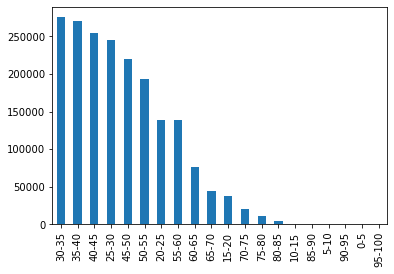

In [28]:
#drop the rows where age is 9999 or 100 or 0 or 1 
uniqueAgeForEachCustomerAndEachPolicyNo=uniqueAgeForEachCustomerAndEachPolicyNo[~uniqueAgeForEachCustomerAndEachPolicyNo['age'].isin([9999,100,0,1])]
#divide the age into different age group, for example age at 46 belongs to the age group 46-50, age at 42 belongs to the age group 40-45, value count of each age group then plot graph to show the distribution of age group using seaborn
uniqueAgeForEachCustomerAndEachPolicyNo['age_gp']=pd.cut(uniqueAgeForEachCustomerAndEachPolicyNo['age'],bins=[0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100],labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','60-65','65-70','70-75','75-80','80-85','85-90','90-95','95-100'])
uniqueAgeForEachCustomerAndEachPolicyNo['age_gp'].value_counts().plot(kind="bar")


In [32]:
uniqueAgeForEachCustomerAndEachPolicyNo['age_gp']

4150590    50-55
5614967    40-45
4128254    45-50
4128258    45-50
4248057    45-50
           ...  
6552669    35-40
6553079    45-50
6553083    45-50
6615917    55-60
6625552    20-25
Name: age_gp, Length: 1930626, dtype: category
Categories (20, object): ['0-5' < '5-10' < '10-15' < '15-20' ... '80-85' < '85-90' < '90-95' < '95-100']

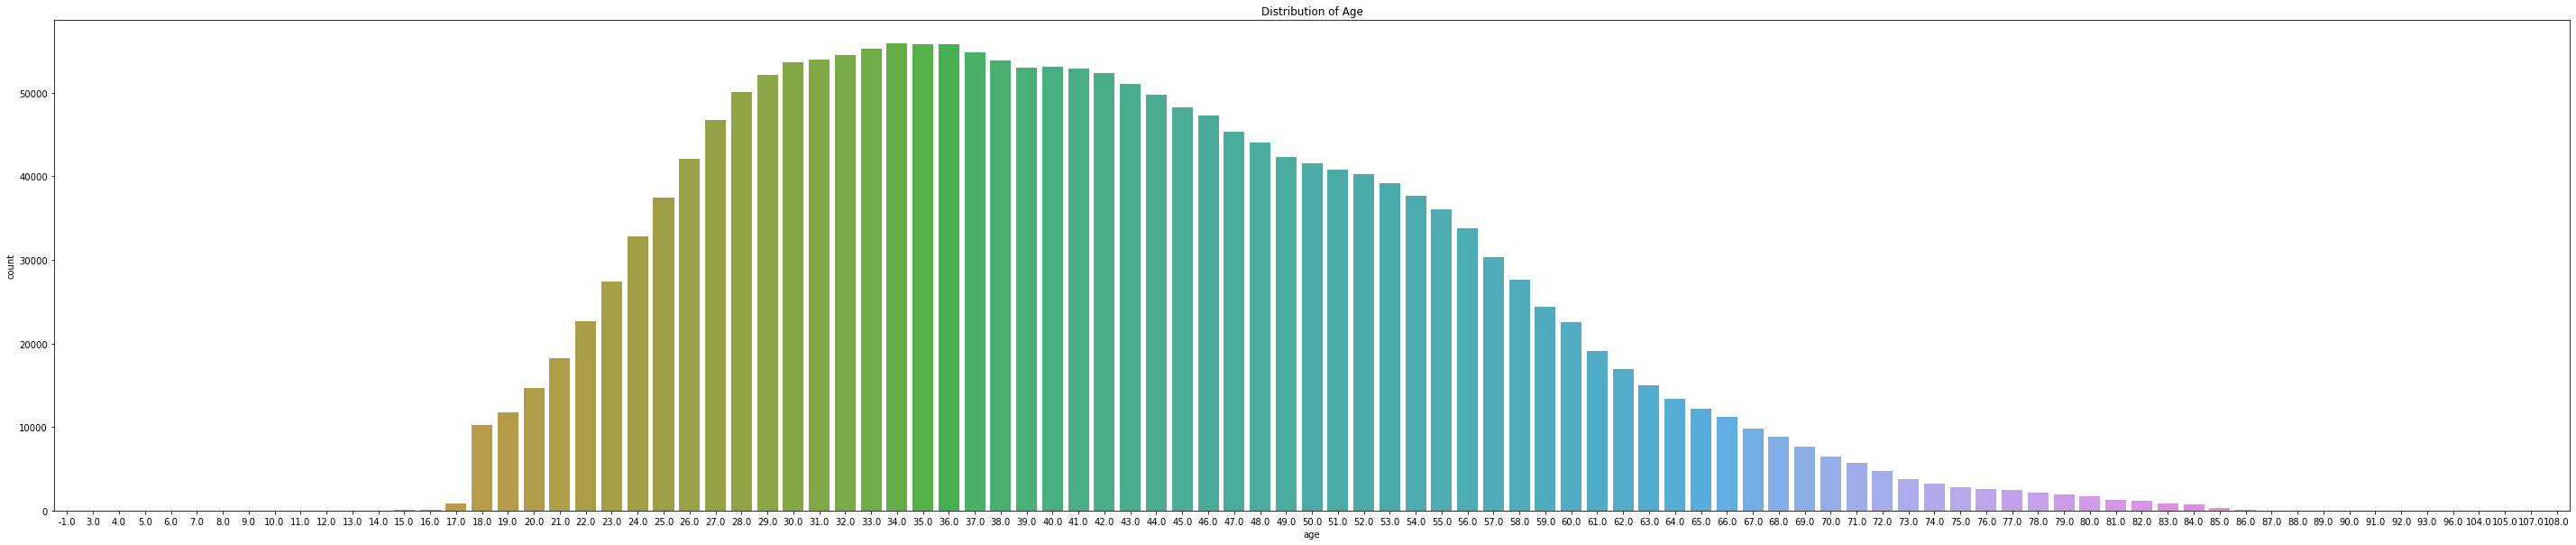

In [39]:
# plot graph using seaborn to show the value count of age_gp 
plt.figure(figsize=(50,10))
df=uniqueAgeForEachCustomerAndEachPolicyNo
sns.countplot(x='age',data =df)
plt.title('Distribution of Age')
plt.show()


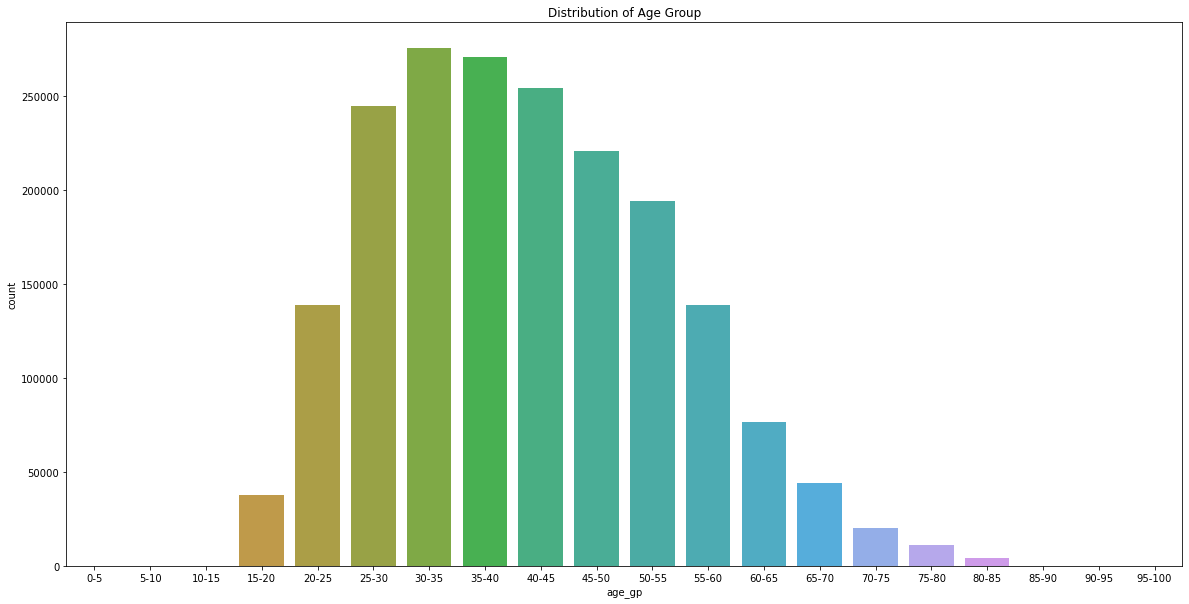

In [37]:
# plot graph using seaborn to show the value count of age_gp 
plt.figure(figsize=(20,10))
df=uniqueAgeForEachCustomerAndEachPolicyNo
sns.countplot(x='age_gp',data =df)
plt.title('Distribution of Age Group')
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(50,10))
sns.countplot(x='age_gp',data =uniqueAgeForEachCustomerAndEachPolicyNo)
plt.show()

3874598    NaN
3876744    NaN
4014282    NaN
4014367    NaN
4020882    NaN
          ... 
6675726    NaN
6675727    NaN
6675731    NaN
6675732    NaN
6675814    NaN
Name: new_age_gp, Length: 1987340, dtype: category
Categories (10, object): ['0-10' < '10-20' < '20-30' < '30-40' ... '60-70' < '70-80' < '80-90' < '90-100']

In [1]:
#value count of age(without age == 0) with bin==20 then plot the result
uniqueAgeForEachCustomerAndEachPolicyNo[uniqueAgeForEachCustomerAndEachPolicyNo['age']!=9999]['age'].value_counts(bins=10,sort=False,dropna=False).plot(kind='bar',figsize=(15,10))


NameError: name 'uniqueAgeForEachCustomerAndEachPolicyNo' is not defined

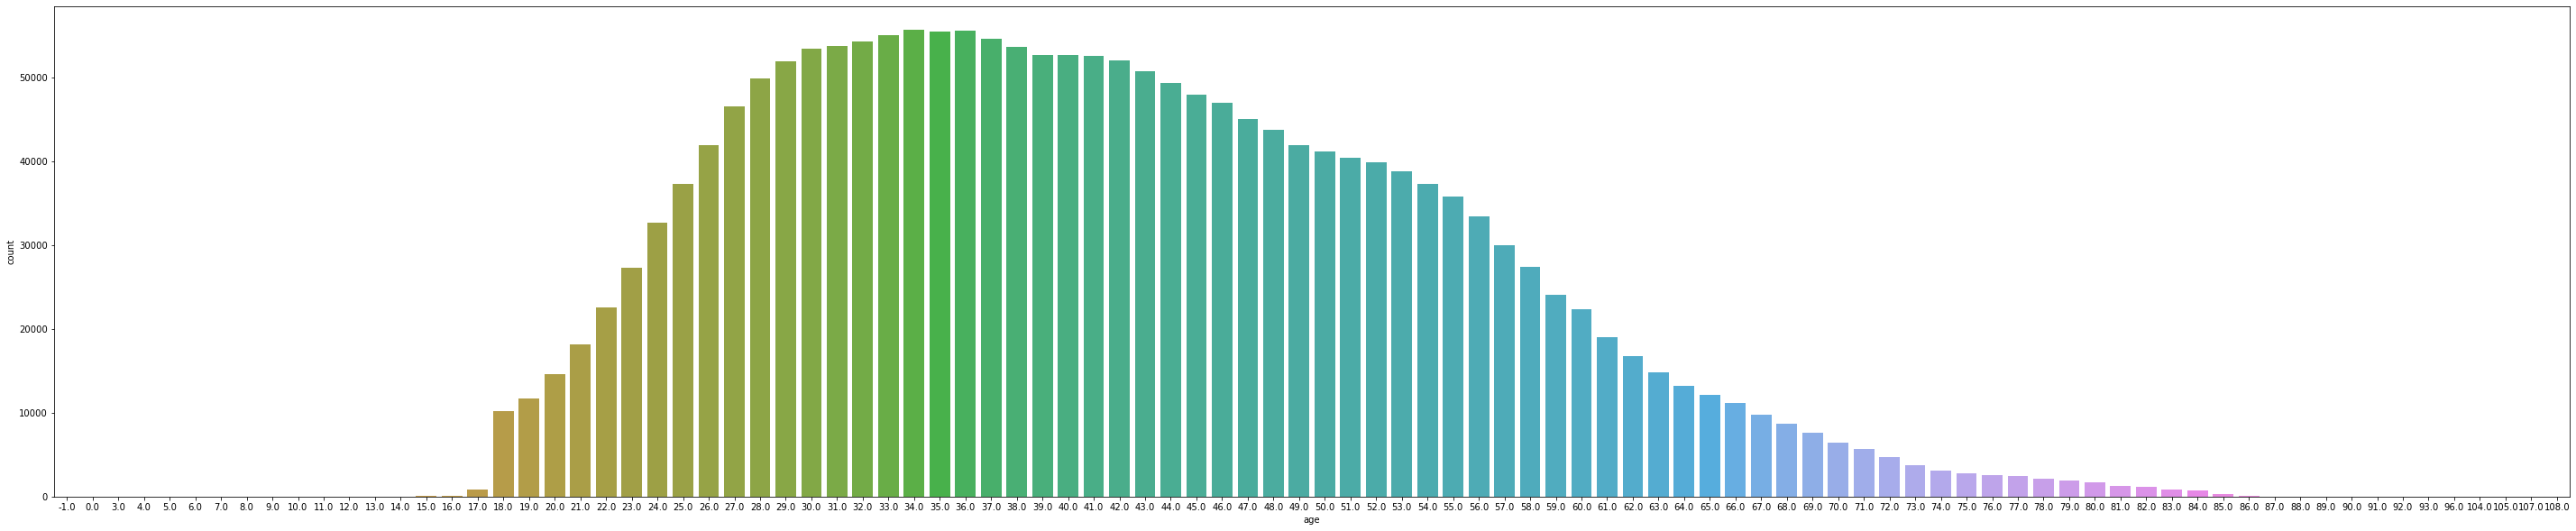

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(50,10))
df=uniqueAgeForEachCustomerAndEachPolicyNo[ ~(uniqueAgeForEachCustomerAndEachPolicyNo['age'] == 9999) ]
sns.countplot(x='age',data =df)
plt.show()


In [128]:
uniqueAge_GpForEachCustomerAndEachPolicyNo=sample.loc[sample.groupby(['modified_SECUITYNO','contrnb'])['age_gp'].idxmin()]

In [129]:
uniqueAge_GpForEachCustomerAndEachPolicyNo['age_gp'].value_counts()

3. Age 31 - 40     546117
4. Age 41 - 50     474812
2. Age 17 - 30     420953
5. Age 51 - 60     332451
6. Age 61 - 70     120549
9. unknown          56708
7. Age 71 - 80      31039
8. Age 80 +          4484
1. Less than 16       227
Name: age_gp, dtype: int64

In [137]:
uniqueAge_GpForEachCustomerAndEachPolicyNo[(uniqueAge_GpForEachCustomerAndEachPolicyNo['age_gp']=='9. unknown') & ~(uniqueAge_GpForEachCustomerAndEachPolicyNo['age']==9999)]

,modified_SECUITYNO,age,age_gp,OCCDATE,contrnb,BIRTH_DATE,AGE_AT_ISSUE,ID_NO,POLICY_NO


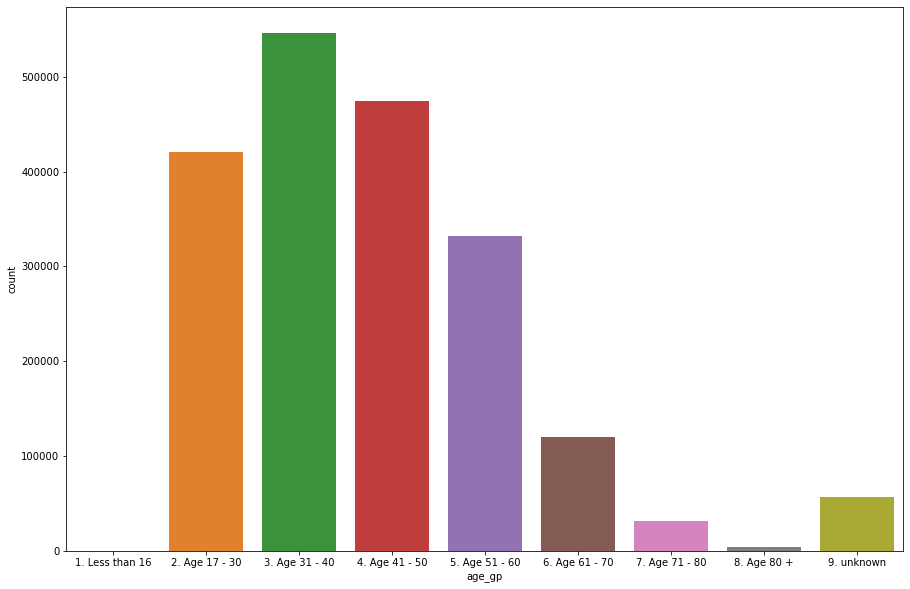

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
df=uniqueAge_GpForEachCustomerAndEachPolicyNo 
# [ ~(uniqueAge_GpForEachCustomerAndEachPolicyNo['age_gp'] == 9999) ]
sns.countplot(x='age_gp',data =df)
plt.show()

In [ ]:
#% with birthday
(950505/5264810) *100

In [ ]:
(5264810/5264810)*100

In [ ]:
sample[~(sample['BIRTH_DATE'].isnull())]
# [ ~(DF_in_desired_timerage['age'] == 9999) ]


In [ ]:
sample[~(sample['age'].isnull())]

# AGE of year 2023

In [178]:
ageOfYear2023=clients_wo_medical[['modified_SECUITYNO','age','OCCDATE','contrnb']]
# check how many Nan in age and BIRTH_DATE and AGE_AT_ISSUE
# print(ageOfYear2023['age'].isnull().sum())
# print(ageOfYear2023['BIRTH_DATE'].isnull().sum())
# print(ageOfYear2023['AGE_AT_ISSUE'].isnull().sum())

# value count age and BIRTH_DATE and AGE_AT_ISSUE
# print(ageOfYear2023['age'].value_counts())
# print(ageOfYear2023['BIRTH_DATE'].value_counts())
# print(ageOfYear2023['AGE_AT_ISSUE'].value_counts())
# drop rows where modified_SECUITYNO doesn't make sense (i.e. modified_SECUITYNO is in DUMMY_ID))
ageOfYear2023=ageOfYear2023[~(ageOfYear2023['modified_SECUITYNO'].isin(DUMMY_ID))]
#drop rows where age is 9999 or 100 or 0 or 1
ageOfYear2023=ageOfYear2023[~ageOfYear2023['age'].isin([9999,100,0,1])]

# Create new column OCCYEAR by extracting year from OCCDATE
ageOfYear2023['OCCYEAR']=ageOfYear2023['OCCDATE'].dt.year
# Using the information from column OCCYEAR and age to calculate the age at 2023 and put it into new column Age_at_2023
ageOfYear2023['Age_at_2023']=2023-ageOfYear2023['OCCYEAR']+ageOfYear2023['age']
# drop duplicate rows based on modified_SECUITYNO
ageOfYear2023=ageOfYear2023.drop_duplicates(subset=['modified_SECUITYNO','Age_at_2023'])
print(ageOfYear2023)

# value count of Age_at_2023 
ageOfYear2023['Age_at_2023'].value_counts().sort_index()

# ageOfYear2023=ageOfYear2023[~(ageOfYear2023['modified_SECUITYNO']=='unknown')]


        modified_SECUITYNO   age    OCCDATE   contrnb  OCCYEAR  Age_at_2023
0                  D573231  50.0 2011-12-13  00300028     2011         62.0
2                  D573231  51.0 2011-12-13  00300028     2011         63.0
4                  D573231  52.0 2011-12-13  00300028     2011         64.0
6                  D573231  53.0 2011-12-13  00300028     2011         65.0
8                  D573231  54.0 2011-12-13  00300028     2011         66.0
...                    ...   ...        ...       ...      ...          ...
6675676            D850301  50.0 2022-10-07  Z1815346     2022         51.0
6675680            Z294034  42.0 2022-10-25  Z1915644     2022         43.0
6675689            C571692  54.0 2022-10-24  Z1915945     2022         55.0
6675729            D207104  60.0 2022-10-28  Z1916764     2022         61.0
6675807            Z116795  38.0 2022-10-25  Z1917095     2022         39.0

[952540 rows x 6 columns]


7.0       1
11.0      2
12.0      1
13.0      3
14.0      2
         ..
102.0    10
103.0     2
109.0     1
111.0     3
122.0     1
Name: Age_at_2023, Length: 95, dtype: int64

<AxesSubplot:>

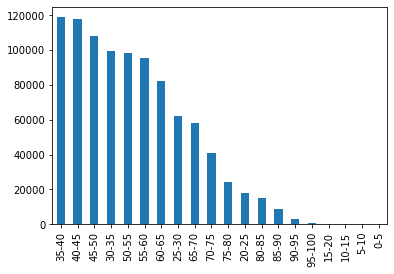

In [179]:
#divide the Age_at_2023 into different age group, for example age at 46 belongs to the age group 46-50, age at 42 belongs to the age group 40-45, value count of each age group then plot graph to show the distribution of age group using seaborn
ageOfYear2023['Age_at_2023_gp']=pd.cut(ageOfYear2023['Age_at_2023'],bins=[0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,100],labels=['0-5','5-10','10-15','15-20','20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','60-65','65-70','70-75','75-80','80-85','85-90','90-95','95-100'])
ageOfYear2023['Age_at_2023_gp'].value_counts().plot(kind="bar")


In [180]:
#show modified_SECUITYNO and Age_at_2023_gp
ageOfYear2023[['modified_SECUITYNO','Age_at_2023_gp']]


,modified_SECUITYNO,Age_at_2023_gp
0,D573231,60-65
2,D573231,60-65
4,D573231,60-65
6,D573231,60-65
8,D573231,65-70
...,...,...
6675676,D850301,50-55
6675680,Z294034,40-45
6675689,C571692,50-55
6675729,D207104,60-65


In [181]:
#drop duplicate rows based on modified_SECUITYNO and Age_at_2023_gp
ageOfYear2023=ageOfYear2023.drop_duplicates(subset=['modified_SECUITYNO','Age_at_2023_gp'])


In [182]:
ageOfYear2023[['modified_SECUITYNO','Age_at_2023_gp']]

,modified_SECUITYNO,Age_at_2023_gp
0,D573231,60-65
8,D573231,65-70
14,M009061,35-40
18,M009061,40-45
36,R629644,60-65
...,...,...
6675580,K069370,50-55
6675585,K101556,45-50
6675645,Z953663,30-35
6675676,D850301,50-55


In [185]:
#value count of Age_at_2023_gp
ageOfYear2023['Age_at_2023_gp'].value_counts()

35-40     93058
40-45     89812
45-50     80694
30-35     79753
50-55     71875
55-60     68546
60-65     57899
25-30     51986
65-70     39614
70-75     27085
20-25     16052
75-80     14509
80-85      8534
85-90      4946
90-95      1323
95-100      348
15-20       330
10-15         7
5-10          1
0-5           0
Name: Age_at_2023_gp, dtype: int64

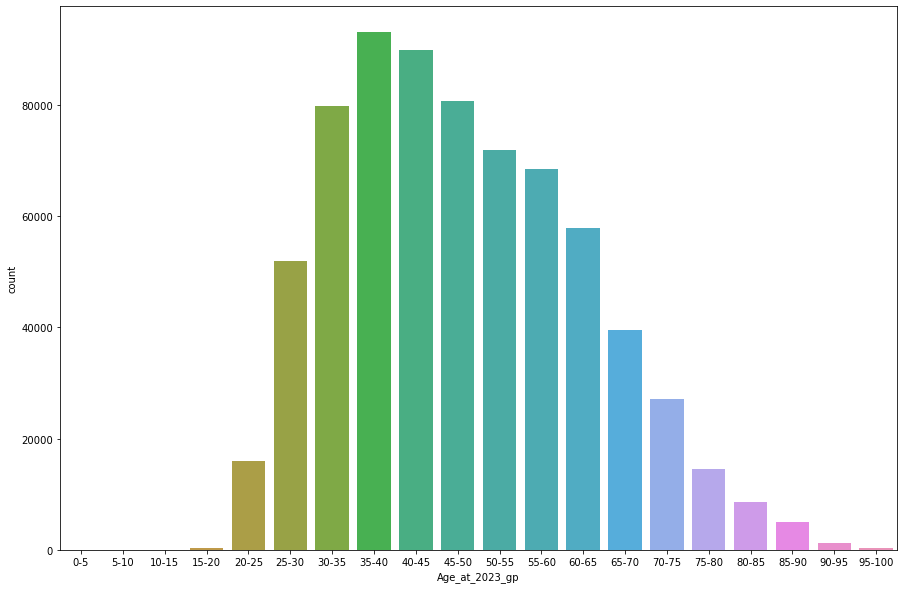

In [186]:
# plot graph using seaborn to show the value count of Age_at_2023_gp
plt.figure(figsize=(15,10))
sns.countplot(x='Age_at_2023_gp',data =ageOfYear2023)
plt.show()



In [323]:
#group Age_at_2023 into 20 groups then count the number of each group and sort by count in descending order 
ageOfYear2023['Age_at_2023'].value_counts(bins=20,sort=False,dropna=False).sort_values(ascending=False)

(38.0, 44.0]      144449
(32.0, 38.0]      134456
(44.0, 50.0]      130753
(50.0, 56.0]      117070
(56.0, 62.0]      112481
(26.0, 32.0]       88087
(62.0, 68.0]       84493
(68.0, 74.0]       54850
(74.0, 80.0]       31402
(20.0, 26.0]       26825
(80.0, 86.0]       17134
(86.0, 92.0]        7898
(92.0, 98.0]        2066
(14.0, 20.0]         335
(98.0, 104.0]        264
(8.0, 14.0]           10
(1.879, 8.0]           4
(110.0, 116.0]         3
(104.0, 110.0]         1
(116.0, 122.0]         1
Name: Age_at_2023, dtype: int64

<AxesSubplot:>

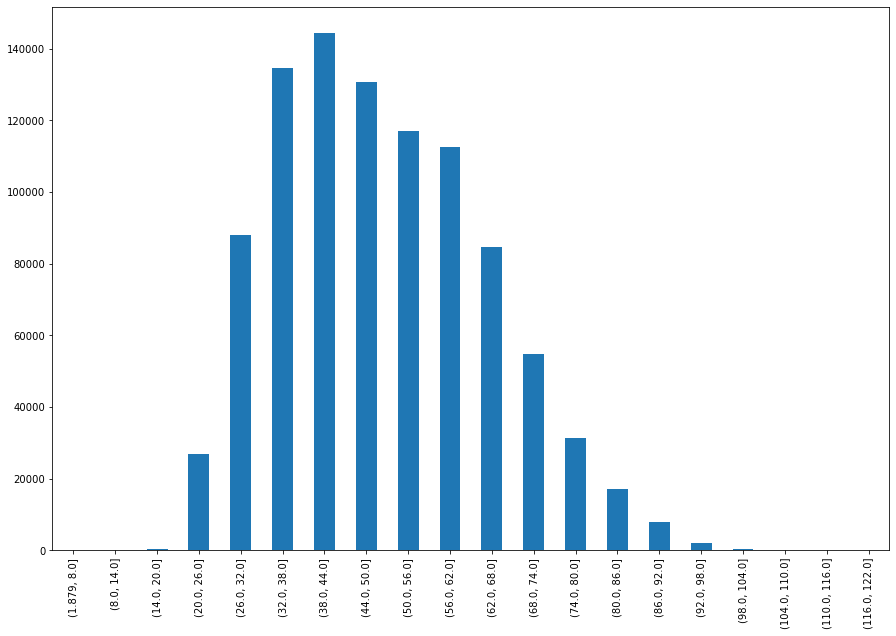

In [324]:
#value count of Age_at_2023 with bin==20 then plot the result
ageOfYear2023['Age_at_2023'].value_counts(bins=20,sort=False,dropna=False).plot(kind='bar',figsize=(15,10))




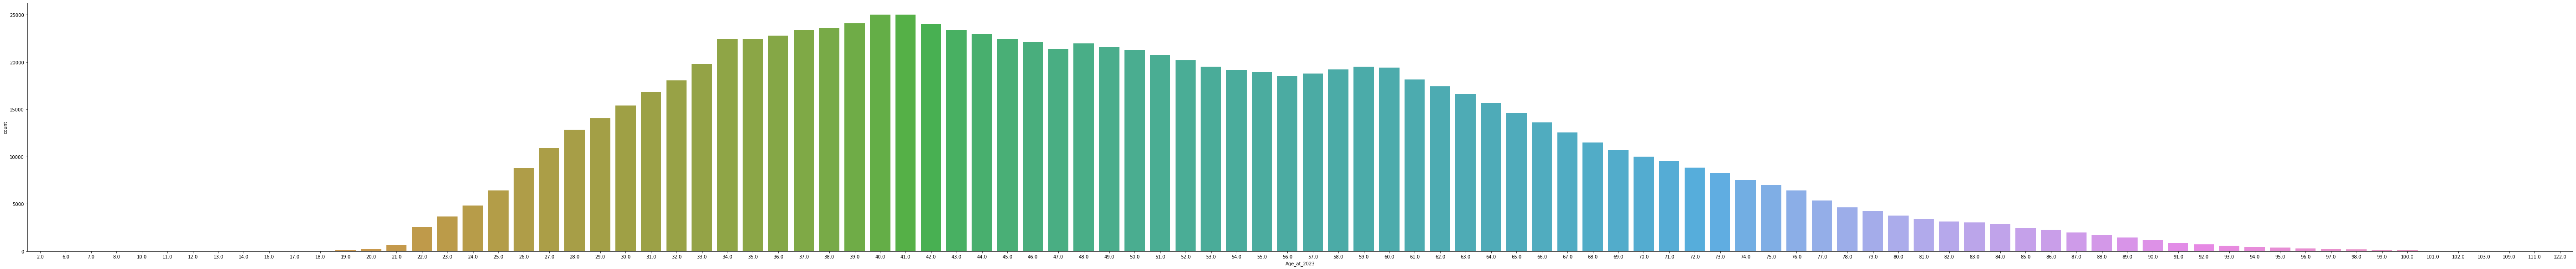

In [218]:
#plot graph using seaborn to show the distribution of Age_at_2023 and group by reasonable age range

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(100,10))
df=ageOfYear2023[ ~(ageOfYear2023['Age_at_2023'] == 9999) ]
sns.countplot(x='Age_at_2023',data =df)
plt.show()


In [245]:
# groupby modified_SECUITYNO and get the minimum age of each customer and put it into new dataframe with the name uniqueAgeforEachCustomer, also get the colume Age_at_2023
uniqueAgeforEachCustomer=ageOfYear2023.loc[ageOfYear2023.groupby(['modified_SECUITYNO'])['age'].idxmin()][['modified_SECUITYNO','age','Age_at_2023']]



,modified_SECUITYNO,age,Age_at_2023
4150590,0000230,54.0,64.0
5614967,0000459,44.0,62.0
4128254,0000494,47.0,57.0
3945814,0000634,56.0,68.0
3893264,0000833,42.0,55.0
3885833,0000847,39.0,52.0
3994966,0000979,45.0,56.0
4186766,0001187,45.0,55.0
5592242,0001395,38.0,59.0
4209716,0001414,57.0,67.0


In [247]:

uniqueAgeforEachCustomer.sample(10)

,modified_SECUITYNO,age,Age_at_2023
4781994,K00551502,61.0,68.0
343306,D803990,45.0,53.0
4398601,G342667,46.0,55.0
1140434,K806547,38.0,45.0
3607873,E972886,57.0,58.0
2346324,Z620293,33.0,38.0
794789,R013813,42.0,49.0
139490,K687905,38.0,46.0
59658,Z538874,35.0,43.0
3876115,0454211,40.0,54.0


In [248]:
# show rows where modified_SECUITYNO = 0000979 in the clients_wo_medical dataframe
clients_wo_medical[clients_wo_medical['modified_SECUITYNO']=='Z620293']

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE_x,CLTSEX_x,CLTDOB_x,MARRYD_x,NATLTY_x,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,OCCDATE_year,CLNTNUM,VALIDFLAG,CLTTYPE_y,SECUITYNO,CLTSEX_y,OCCPCODE,CLTDOB_y,START_DATE,MARRYD_y,NATLTY_y,modified_SECUITYNO,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,owner_id,modified_owner_id,bought_medic_flag
2346324,25408974,2018-05-25,33.0,1.0,1.0,20180525.0,18.09,5.43,2.01,2018.0,5.0,1.0,2018-05-12,T405,STR,2018-05-25,20180529.0,None,2664604,E04430,20,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,17.945280,5.43,N,BSTR1017,TravelSurance (single trip),N,P,M,19841230.0,NaN,None,ATH,99999999.0,PA,NaN,600000.0,I,I1,1,1.0,N,Single,20180529.0,NaN,0.0,99999999.0,5.0,1.0,Area 1,Self Only,N,NA,3. 4-5 Days,NWBS,HSBC - Dummy,637(SURANCE)-NET,9998,Banca - HSBC,0.0,TravelSurance,13.0,4. 11 to 15 days,1. 1 person,3. Age 31 - 40,-0.0,Single,NaN,NaN,NaN,1. Discount = 1% to 10%,2018,2664604,1,P,Z620293(5),M,None,19841230.0,20180512.0,None,None,Z620293,NaN,NaN,None,NaT,NaN,NaN,NaN,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,None,None,None,NaN,None,None,None,0
2346325,25408974,2018-05-25,33.0,2.0,1.0,20180525.0,102.51,30.75,11.39,2018.0,5.0,1.0,2018-05-12,T405,STR,2018-05-25,20180529.0,None,2664604,E04430,20,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,101.689920,30.75,N,BSTR1017,TravelSurance (single trip),N,P,M,19841230.0,NaN,None,ATM,99999999.0,Miscellaneous,NaN,600000.0,I,I1,1,NaN,N,Single,20180529.0,NaN,0.0,99999999.0,0.0,NaN,Area 1,Self Only,N,NA,3. 4-5 Days,NWBS,HSBC - Dummy,637(SURANCE)-NET,9998,Banca - HSBC,0.0,TravelSurance,13.0,4. 11 to 15 days,1. 1 person,3. Age 31 - 40,-0.0,Single,NaN,NaN,NaN,1. Disco

<AxesSubplot:>

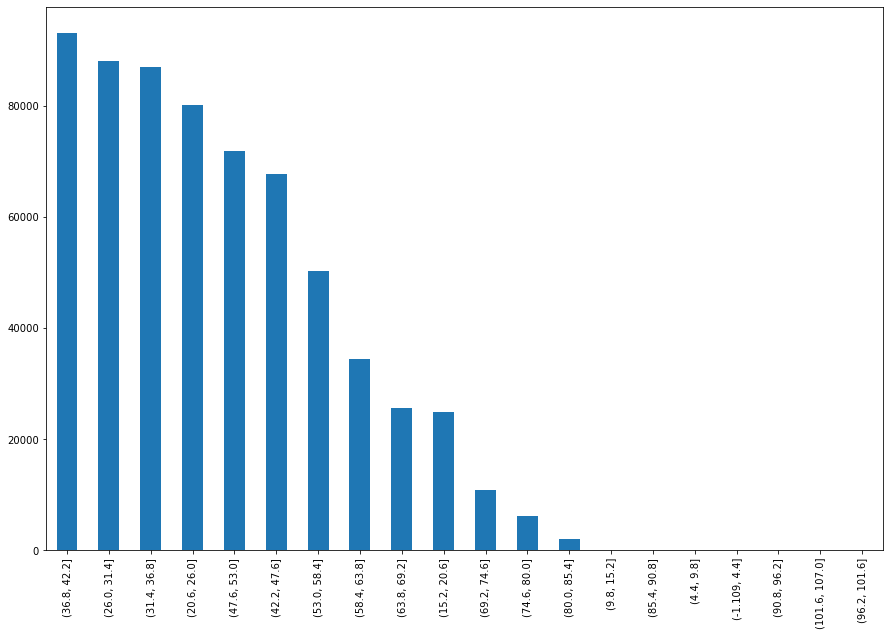

In [249]:
#value count of age with bin==20 then plot the result
uniqueAgeforEachCustomer['age'].value_counts(bins=20,sort=False,dropna=False).sort_values(ascending=False).plot(kind='bar',figsize=(15,10))

# Gender

In [190]:
gender=clients_wo_medical[['modified_SECUITYNO','CLTSEX_y', 'CLTSEX_x']]
#drop modified_SECUITYNO that is in DUMMY_ID

gender[gender['modified_SECUITYNO'].isin(DUMMY_ID)]

gender.head(10)
gender[~gender['CLTSEX_y'].isna()]
gender[~gender['CLTSEX_x'].isna()]
gender[gender['CLTSEX_x']=='F']
def newsex(row):
    # if row['CLTSEX_y']== np.NaN or row['CLTSEX_x']== np.NaN:
    #     print(row['modified_SECUITYNO'])
    if row['CLTSEX_y']==row['CLTSEX_x']:
        return row['CLTSEX_x']
    elif row['CLTSEX_y']=='F' or 'M':
        return row['CLTSEX_y']
    elif row['CLTSEX_x']=='F' or 'M':
        return row['CLTSEX_x']
    return row['CLTSEX_x']
gender['new_sex']=gender.apply(newsex,axis=1)
# gender
genderDropDuplicate=gender.drop_duplicates(subset=['modified_SECUITYNO','new_sex'],keep='first')
# genderDropDuplicate

# genderDropDuplicate


C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_21544/2290459833.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gender['new_sex']=gender.apply(newsex,axis=1)


F    0.560107
M    0.438183
U    0.001710
Name: new_sex, dtype: float64

In [192]:
#value counts and output as table


genderDropDuplicate['new_sex'].value_counts(dropna=False)

F      321073
M      251182
NaN    115156
U         980
Name: new_sex, dtype: int64

In [ ]:
plt.figure(figsize=(25,50))
df=genderDropDuplicate
sns.countplot(x='new_sex',data =df)
plt.show()

# percentage of long-term vs short-term travel plan

In [56]:
clients_wo_medical

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE_x,CLTSEX_x,CLTDOB_x,MARRYD_x,NATLTY_x,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,OCCDATE_year,CLNTNUM,VALIDFLAG,CLTTYPE_y,SECUITYNO,CLTSEX_y,OCCPCODE,CLTDOB_y,START_DATE,MARRYD_y,NATLTY_y,modified_SECUITYNO,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,owner_id,modified_owner_id,bought_medic_flag
0,00300028,20151213.0,50.0,1.0,2.0,20151213.0,423.9,127.17,0.0,2015.0,12.0,1.0,2015-12-05,T413,STX,2011-12-13,20161212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,417.75345,127.17,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATH,99999999.0,PA,NaN,1000000.0,C,C2,2,1.0,N,Annual,20161212.0,NaN,0.0,99999999.0,366.0,1.0,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,8.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,4.0,4,NaN,NaN,NaN,0. No Discount,2011,N5017122,1,P,D573231(0),M,UNKN,19651212.0,99999999.0,M,None,D573231,NaN,NaN,None,NaT,NaN,NaN,NaN,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,None,None,None,NaN,None,None,None,0
1,00300028,20151213.0,50.0,2.0,2.0,20151213.0,2402.1,720.63,0.0,2015.0,12.0,1.0,2015-12-05,T413,STX,2011-12-13,20161212.0,None,N5017122,E03158,20,0.0,27 - Travel Insurance,N,AXA,N,N,HB,RNWL,2367.26955,720.63,N,N,MultiTrip TravelSurance (Annual),N,P,M,19651212.0,M,None,ATM,99999999.0,Miscellaneous,NaN,1000000.0,C,C2,2,NaN,N,Annual,20161212.0,NaN,0.0,99999999.0,0.0,NaN,Area 2,Self & Children,N,NA,Annual,RNWL,HSBC - Dummy,608(SURANCE)-ILD,9998,Banca - HSBC,0.0,TravelSurance,8.0,3. 6 to 10 days,1. 1 person,4. Age 41 - 50,4.0,4,NaN,NaN,NaN,0. No Discount,2011,N5017122,1,P,D573231(0

In [242]:
clients_wo_medical.groupby("OCCDATE").agg({"CCDATE": [min-max]})

TypeError: unsupported operand type(s) for -: 'builtin_function_or_method' and 'builtin_function_or_method'

In [57]:
longShortTerm=clients_wo_medical[['contrnb','OCCDATE','CCDATE']]

In [58]:
clients_wo_medical["CCDATE"] = pd.to_datetime(clients_wo_medical["CCDATE"], format="%Y%m%d")

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/4169118847.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clients_wo_medical["CCDATE"] = pd.to_datetime(clients_wo_medical["CCDATE"], format="%Y%m%d")


In [59]:
# convert column CCDATE to datetime 
longShortTerm["CCDATE"] = pd.to_datetime(longShortTerm["CCDATE"], format="%Y%m%d")

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/2836298069.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longShortTerm["CCDATE"] = pd.to_datetime(longShortTerm["CCDATE"], format="%Y%m%d")


In [60]:
longShortTerm["CCDATE"] 

0         2015-12-13
1         2015-12-13
2         2016-12-13
3         2016-12-13
4         2017-12-13
             ...    
6676747   2022-10-26
6676748   2021-05-26
6676749   2021-05-26
6676750   2016-03-19
6676751   2016-03-19
Name: CCDATE, Length: 4100574, dtype: datetime64[ns]

In [62]:
#latest occdate - first occdate
longShortTerm['cc_min']=longShortTerm.groupby("contrnb")['CCDATE'].transform('min')

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/1419443204.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longShortTerm['cc_min']=longShortTerm.groupby("contrnb")['CCDATE'].transform('min')


In [63]:
longShortTerm['cc_max']=longShortTerm.groupby("contrnb")['CCDATE'].transform('max')

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/230764297.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longShortTerm['cc_max']=longShortTerm.groupby("contrnb")['CCDATE'].transform('max')


In [64]:
longShortTerm[longShortTerm['contrnb']=='00300028']

,contrnb,OCCDATE,CCDATE,cc_min,cc_max
0,00300028,2011-12-13,2015-12-13,2015-12-13,2019-12-13
1,00300028,2011-12-13,2015-12-13,2015-12-13,2019-12-13
2,00300028,2011-12-13,2016-12-13,2015-12-13,2019-12-13
3,00300028,2011-12-13,2016-12-13,2015-12-13,2019-12-13
4,00300028,2011-12-13,2017-12-13,2015-12-13,2019-12-13
5,00300028,2011-12-13,2017-12-13,2015-12-13,2019-12-13
6,00300028,2011-12-13,2018-12-13,2015-12-13,2019-12-13
7,00300028,2011-12-13,2018-12-13,2015-12-13,2019-12-13
8,00300028,2011-12-13,2019-12-13,2015-12-13,2019-12-13
9,00300028,2011-12-13,2019-12-13,2015-12-13,2019-12-13


In [68]:
longShortTerm['ccdate_diff']=longShortTerm['cc_max']-longShortTerm['cc_min']

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/2355461468.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longShortTerm['ccdate_diff']=longShortTerm['cc_max']-longShortTerm['cc_min']


In [69]:
longShortTerm['ccdate_diff']

0         1461 days
1         1461 days
2         1461 days
3         1461 days
4         1461 days
             ...   
6676747      0 days
6676748      0 days
6676749      0 days
6676750      0 days
6676751      0 days
Name: ccdate_diff, Length: 4100574, dtype: timedelta64[ns]

In [70]:
longShortTerm[longShortTerm['contrnb']=='00300028']

,contrnb,OCCDATE,CCDATE,cc_min,cc_max,ccdate_diff
0,00300028,2011-12-13,2015-12-13,2015-12-13,2019-12-13,1461 days
1,00300028,2011-12-13,2015-12-13,2015-12-13,2019-12-13,1461 days
2,00300028,2011-12-13,2016-12-13,2015-12-13,2019-12-13,1461 days
3,00300028,2011-12-13,2016-12-13,2015-12-13,2019-12-13,1461 days
4,00300028,2011-12-13,2017-12-13,2015-12-13,2019-12-13,1461 days
5,00300028,2011-12-13,2017-12-13,2015-12-13,2019-12-13,1461 days
6,00300028,2011-12-13,2018-12-13,2015-12-13,2019-12-13,1461 days
7,00300028,2011-12-13,2018-12-13,2015-12-13,2019-12-13,1461 days
8,00300028,2011-12-13,2019-12-13,2015-12-13,2019-12-13,1461 days
9,00300028,2011-12-13,2019-12-13,2015-12-13,2019-12-13,1461 days


In [71]:
result=longShortTerm.drop_duplicates(subset=['contrnb', 'ccdate_diff'], keep='last')

In [73]:
result['nb_years']=((result.cc_max - result.cc_min)/np.timedelta64(1, 'Y'))
result['nb_years'] = result['nb_years'].astype(int)

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/1939401999.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['nb_years']=((result.cc_max - result.cc_min)/np.timedelta64(1, 'Y'))
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/1939401999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['nb_years'] = result['nb_years'].astype(int)


In [74]:
result['nb_months']=((result.cc_max - result.cc_min)/np.timedelta64(1, 'M'))
result['nb_months'] = result['nb_months'].astype(int)

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/3971971916.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['nb_months']=((result.cc_max - result.cc_min)/np.timedelta64(1, 'M'))
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/3971971916.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['nb_months'] = result['nb_months'].astype(int)


In [75]:
result['nb_days']=((result.cc_max - result.cc_min)/np.timedelta64(1, 'D'))
result['nb_days'] = result['nb_days'].astype(int)

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/1391560311.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['nb_days']=((result.cc_max - result.cc_min)/np.timedelta64(1, 'D'))
C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_13380/1391560311.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result['nb_days'] = result['nb_days'].astype(int)


In [76]:
result['nb_days'].value_counts().sort_index()

0       1945014
30            1
31            3
68            3
88            1
         ...   
7083          1
7117          1
7215          2
7305          9
7397          1
Name: nb_days, Length: 385, dtype: int64

In [78]:
longShortTerm.shape


(4100574, 6)

In [77]:
result['nb_years'].value_counts().sort_index()

0     1966565
1       19460
2        9197
3        6081
4        8677
5        4456
6        2594
7        1488
8         578
9         236
10        148
11        137
12        176
13         60
14         51
15         42
16         64
17         25
18         14
19         25
20         10
Name: nb_years, dtype: int64

In [79]:
result['nb_months'].value_counts().sort_index()

0      1945015
1            3
2            4
4            1
5            2
        ...   
232          1
233          1
237          2
240          9
243          1
Name: nb_months, Length: 165, dtype: int64

<AxesSubplot:>

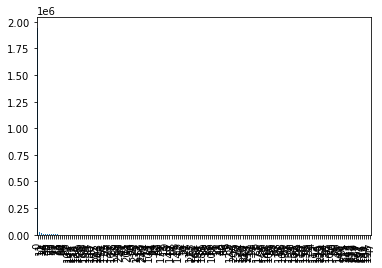

In [93]:
result['nb_months'].value_counts().plot(kind='bar') 

In [80]:
result[ (result['nb_months'] < 12)]['nb_months'].value_counts().sort_index()

0     1945015
1           3
2           4
4           1
5           2
6           3
7           2
8           4
9           5
10          4
11      21522
Name: nb_months, dtype: int64

In [91]:
result[ (result['nb_days'] < 367)]['nb_days'].value_counts().sort_index()

0      1945014
30           1
31           3
68           3
88           1
126          1
158          1
165          1
183          1
184          1
196          1
214          1
229          1
245          1
255          1
271          1
273          1
274          4
291          1
305          1
329          1
334          2
336          5
340          1
352          1
353          2
355          2
356          2
359          1
361          2
362          1
363          4
364          7
365      21494
366      13990
Name: nb_days, dtype: int64

In [92]:
result[result['nb_days']==364]

,contrnb,OCCDATE,CCDATE,occ_min,occ_max,ccdate_diff,nb_months,nb_years,nb_days
4520506,S5184915,2015-06-01,2016-05-30,2015-06-01,2016-05-30,364 days,11,0,364
4803220,S5252241,2016-05-11,2017-05-10,2016-05-11,2017-05-10,364 days,11,0,364
5905908,Z0850375,2016-12-16,2017-12-15,2016-12-16,2017-12-15,364 days,11,0,364
5943136,Z0886387,2017-05-28,2018-05-27,2017-05-28,2018-05-27,364 days,11,0,364
6291965,Z1098368,2018-09-01,2019-08-31,2018-09-01,2019-08-31,364 days,11,0,364
6606845,Z1394394,2020-08-17,2021-08-16,2020-08-17,2021-08-16,364 days,11,0,364
6607817,Z1398526,2020-09-18,2021-09-17,2020-09-18,2021-09-17,364 days,11,0,364


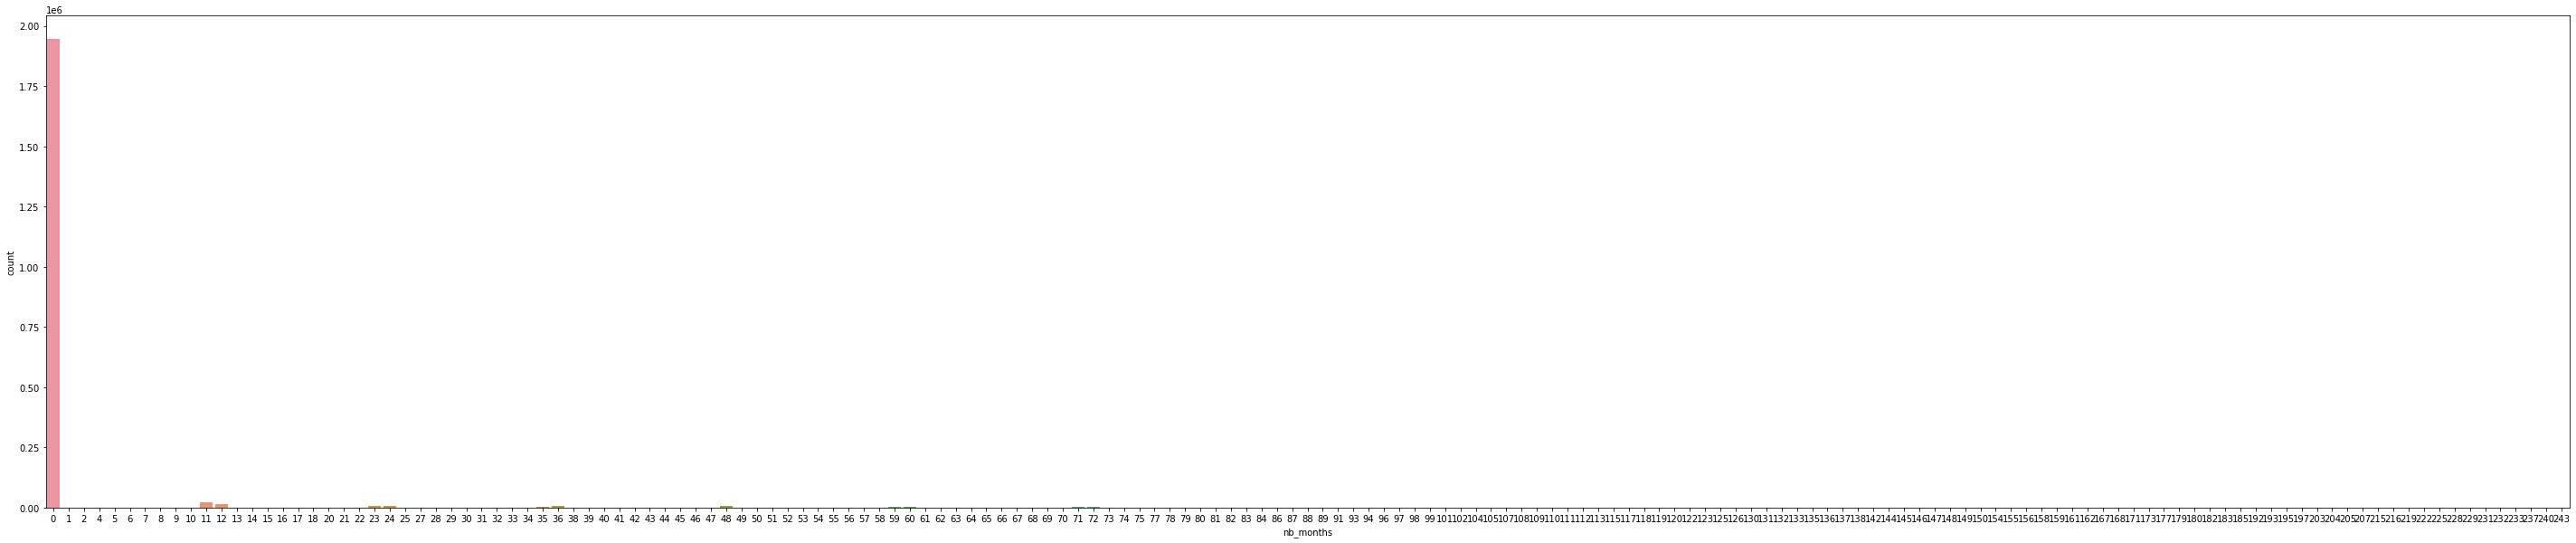

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(50,10))
df=result
# [~(result['nb_months'] ==0)]
sns.countplot(x='nb_months',data =df)
plt.show()

In [167]:
agg=clients_wo_medical.groupby("OCCDATE").agg({"CCDATE": [min, max]})

In [173]:
clients_wo_medical.groupby("OCCDATE").agg({"CCDATE": [min, max]}).unstack()

             OCCDATE   
CCDATE  min  2002-01-01    20020101.0
             2002-01-03    20150703.0
             2002-01-07    20150707.0
             2002-01-15    20150615.0
             2002-01-16    20150616.0
                              ...    
        max  2023-01-18    20230118.0
             2023-01-19    20230119.0
             2023-01-20    20230120.0
             2023-01-21    20230121.0
             2023-01-23    20230123.0
Length: 15266, dtype: float64

In [168]:
agg

CCDATE            
                   min         max
OCCDATE                           
2002-01-01  20020101.0  20020101.0
2002-01-03  20150703.0  20170703.0
2002-01-07  20150707.0  20221007.0
2002-01-15  20150615.0  20180115.0
2002-01-16  20150616.0  20221016.0
...                ...         ...
2023-01-18  20230118.0  20230118.0
2023-01-19  20230119.0  20230119.0
2023-01-20  20230120.0  20230120.0
2023-01-21  20230121.0  20230121.0
2023-01-23  20230123.0  20230123.0

[7633 rows x 2 columns]

In [169]:
agg.iloc[0]

CCDATE  min    20020101.0
        max    20020101.0
Name: 2002-01-01 00:00:00, dtype: float64

In [170]:
agg['CCDATE']['ccdate_diff']=agg['CCDATE']['max'] - agg['CCDATE']['min']

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_5636/1556772772.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg['CCDATE']['ccdate_diff']=agg['CCDATE']['max'] - agg['CCDATE']['min']


In [171]:
agg['CCDATE']['ccdate_diff']

KeyError: 'ccdate_diff'

In [151]:
longShortTerm["ccdate_min"] =agg['CCDATE']['min']

C:\Users\NICOLE~1.LEU\AppData\Local\Temp/ipykernel_5636/3742707534.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  longShortTerm["ccdate_min"] =agg['CCDATE']['min']


In [ ]:
diff=longShortTerm['contrnb']

# channels

In [105]:
channel=clients_wo_medical[['modified_SECUITYNO','contrnb','channel']]

In [108]:
channel.groupby("channel")["modified_SECUITYNO"].nunique()

channel
AXA Offline Direct     11679
AXA Online Direct      55002
Agents & Broker       177927
Banca - HSBC          356922
Citi                   16318
JLT (OSC)               1728
LP                     72920
Name: modified_SECUITYNO, dtype: int64

In [117]:
channel.groupby("channel")["contrnb"].nunique()

channel
AXA Offline Direct      34079
AXA Online Direct       94466
Agents & Broker        425607
Banca - HSBC          1301235
Citi                    30656
JLT (OSC)                2480
LP                     131769
Name: contrnb, dtype: int64

In [111]:
channel.groupby("modified_SECUITYNO")["channel"].nunique().sort_values()

modified_SECUITYNO
           1
R563880    1
R563925    1
R563950    1
R563957    1
          ..
A123456    5
K469014    5
K570574    5
F123456    5
unknown    7
Name: channel, Length: 649161, dtype: int64

In [113]:
channel[channel['modified_SECUITYNO']=='K469014']

,modified_SECUITYNO,contrnb,channel
284960,K469014,24413087,Banca - HSBC
284961,K469014,24413087,Banca - HSBC
5532803,K469014,S5498575,Citi
5532804,K469014,S5498575,Citi
5568427,K469014,S7008791,AXA Online Direct
5568447,K469014,S7008811,AXA Online Direct
5587350,K469014,Z0032372,Agents & Broker
5596913,K469014,Z0071145,Agents & Broker
5597425,K469014,Z0073464,Agents & Broker
5618258,K469014,Z0190023,AXA Offline Direct


# percentage of inforce vs lapse

In [368]:
basestat_df = pd.read_parquet(BASESTAT_FILE)


In [369]:
basestat_df['period'].value_counts(dropna=False)

20170101.0    924367
20180101.0    919784
20160101.0    914951
20190101.0    910862
20150101.0    581238
20200101.0    343342
20220101.0    193723
20210101.0    187965
20140101.0    109999
Name: period, dtype: int64

In [371]:
percentageOfInOrLa=clients_wo_medical[['modified_SECUITYNO','OCCDATE','contrnb','CCDATE']]

In [393]:
# number of unique modified_SECUITYNO
No_of_Unique_Customers=percentageOfInOrLa['modified_SECUITYNO'].nunique()
No_of_Unique_Customers

590045

In [372]:
print("percentageOfInOrLa size before merge:", percentageOfInOrLa.shape)
#COWNNUM=client number 
# left join prembase_df with client_data_df, using column CLNTNUM from client_data_df and column COWNNUM from prembase_df as key
percentageOfInOrLa = percentageOfInOrLa.merge(basestat_df[['contrnb','if_pol','period']], on="contrnb", how="inner")

print("percentageOfInOrLa size after merge:", percentageOfInOrLa.shape)

percentageOfInOrLa size before merge: (4100574, 4)
percentageOfInOrLa size after merge: (31079540, 6)


In [373]:
percentageOfInOrLa.shape


(31079540, 6)

In [374]:
percentageOfInOrLa=percentageOfInOrLa[['modified_SECUITYNO','contrnb','if_pol','period']].drop_duplicates()

In [375]:
percentageOfInOrLa.shape

(2444891, 4)

In [376]:
percentageOfInOrLa.groupby('modified_SECUITYNO')['contrnb'].nunique().sort_values()

modified_SECUITYNO
M099283                 1
Z170157                 1
Z170173                 1
K804601                 1
K804600                 1
                    ...  
1229886300008192      145
1987044               179
0645101               197
K780087               291
unknown             19698
Name: contrnb, Length: 590045, dtype: int64

In [377]:
percentageOfInOrLa[percentageOfInOrLa['contrnb']=='Z1018416']

,modified_SECUITYNO,contrnb,if_pol,period
30453165,E858803,Z1018416,1.0,20170101.0
30453166,E858803,Z1018416,0.0,20180101.0


In [378]:

clients_wo_medical[clients_wo_medical['contrnb']=='Z1018416']

,contrnb,CCDATE,age,RSKNO,TRANNO,DTEEFF,gwp,commis,disc,BATCACTYR,BATCACTMN,CRATE,TRANDATE,trans_code,CNTTYPE,OCCDATE,CRDATE,REPNUM,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,line,ZDMIND,ACSART,bulk,bulk_name,nbrn,tranat,nwp,commis_n,ri_inward,JACKET,product,bulk_name1,CLTTYPE_x,CLTSEX_x,CLTDOB_x,MARRYD_x,NATLTY_x,RSKTYP,ldteter,risk_des,INSURED,TOTSIL,ZPLNCD,ZPLANCDE,trlarea,znolive,zcmccard_banca,plan1,lastcrdate,cancdate,cancelled,dteeff_term,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,NBRN1,producer,rmisagent,rmiscode,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,OCCDATE_year,CLNTNUM,VALIDFLAG,CLTTYPE_y,SECUITYNO,CLTSEX_y,OCCPCODE,CLTDOB_y,START_DATE,MARRYD_y,NATLTY_y,modified_SECUITYNO,APPROVAL_DATE_FIRST,APPROVAL_DATE_LAST,POLICY_NO,SUBMIT_DATE,ISSUE_DATE,LAST_UW_DATE,FOLLOWUP_DATE,UW_REMARKS_1,UW_REMARKS_2,UW_REMARKS_3,APP_STATUS_CODE,UN_CODE,SUBSTDECLINE_OPTION,POLICY_DATE,EXPIRY_DATE,MEDICAL_CODE,LANGUAGE_FLAG,PAYMENT_MODE,PAYMENT_METHOD,LOCATION_OF_POLICY,MONTHS_DEBITED,POLICY_FACTOR,CURRENCY,TOTAL_LOADING,ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR,MODAL_PREM_EXCLUDE_TOPUP_REGULAR,AGENT_1_CODE,AGENT_2_CODE,INSURED_NAME,SEX,AGE_AT_ISSUE,BIRTH_DATE,ID_NO,MARITAL_STATUS,INCOME_LEVEL,CORR_ADDRESS1,CORR_ADDRESS2,CORR_ADDRESS3,CORR_ADDRESS4,CORR_CITY_CODE,OWNER,OWNER_HKID,OWNER_GENDER,INSURED_PREV_POLICY_NO1,INSURED_PREV_POLICY_NO2,INSURED_PREV_POLICY_NO3,INSURED_PREV_POLICY_NO4,INSURED_PREV_POLICY_NO5,INSURED_PREV_POLICY_NO6,INSURED_PREV_POLICY_NO7,INSURED_PREV_POLICY_NO8,INSURED_PREV_POLICY_NO9,INSURED_PREV_POLICY_NO10,INSURED_PREV_POLICY_NO11,INSURED_PREV_POLICY_NO12,PAYOR_PREV_POLICY_NO1,PAYOR_PREV_POLICY_NO2,PAYOR_PREV_POLICY_NO3,PAYOR_PREV_POLICY_NO4,PAYOR_PREV_POLICY_NO5,PAYOR_PREV_POLICY_NO6,PAYOR_PREV_POLICY_NO7,PAYOR_PREV_POLICY_NO8,PAYOR_PREV_POLICY_NO9,PAYOR_PREV_POLICY_NO10,PAYOR_PREV_POLICY_NO11,PAYOR_PREV_POLICY_NO12,PREPAID_PREMIUM_FLAG,TERM_CONVERSION_FLAG,OWNER_BIRTH_DATE,PLAN_CODE,LIFE_SUM_INSURED,CLASS_CODE,BASIC_PREMIUM_RATE,LOADING,TEMP_LOADING,LOADING_EXPIRY,TEMP_LOADING_YEAR,DIVIDEND_OPTION,EXCLUSION,INDEXATION_OPTION_FOR_BASIC_PLAN,INITIAL_LUMP_SUM_PREMIUM,LUMP_SUM_PREMIUM,UN_LANGUAGE_FLAG,RECEIVE_SMS_FLAG,STATUS_CODE,IS_INFORCE_FLAG,BASE_PLAN_TYPE,owner_id,modified_owner_id,bought_medic_flag
6160043,Z1018416,2017-12-09,56.0,1.0,1.0,20171209.0,1131.0,282.75,0.0,2017.0,11.0,1.0,2017-11-16,T405,STC,2017-12-09,20180103.0,None,1157646,70552,10,0.0,27 - Travel Insurance,N,AXA,N,N,NB,NWBS,1119.3507,282.75,N,STS0116,SmartTraveller (Single),N,P,M,19611129.0,NaN,None,ATP,99999999.0,PA,IO,2000000.0,None,V4,9,2.0,NaN,Single,20180103.0,NaN,0.0,99999999.0,26.0,2.0,VIP,Insured Only,N,N,7. 15-30 Days,NWBS,RAYMOND HUI AGENCY,WONG KWOK KAI MICHAEL,7041,LP,1.0,SmartTraveller,23.0,6. 21 to 25 days,2. 2 people,5. Age 51 - 60,-0.0,Single,NaN,NaN,NaN,0. No Discount,2017,1157646,1,P,E858803(5),M,None,19611129.0,20171116.0,None,None,E858803,NaN,NaN,None,NaT,NaN,NaN,NaN,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,None,NaN,None,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,None,None,None,NaN,None,None,None,0


In [379]:
basestat_df[basestat_df['contrnb']=='Z1018416']

,contrnb,CCDATE,RSKNO,DTEEFF,CNTTYPE,OCCDATE,COWNNUM,AGNTNUM,CNTBRANCH,autorenew,ZDMIND,bulk,bulk_name,nbrn,tranat,product,bulk_name1,CLTSEX,INSURED,ZPLANCDE,trlarea,znolive,plan1,duration,lastznolive,plan2,plan3,ChinaCard,EnhancedPA,duration_grp,producer,rmisagent,channel,lifeagent,product2,gap_trandate_ccdate,gap_trandate_ccdate_gp,znolive_gp,age_gp,loyalty,loyalty_cat,insage_smu,inssex_smu,insage_smu_gp,disc_gp,gwp,nwp,gep,nep,yduration,disc,ypol,ypol_actual,no_pol,no_rsk,commis,commis_n,nec,if_pol,if_rsk,ExpectedCost,TechnicalPremium,MarketingPremium,GWP_initial,APTP_gp,chgbal_g,chgbal_n,paymnt_g,paymnt_n,nb_clm,incur_g,incur_n,ultincur_n,ult_clm,lrg_incur_g,lrg_incur_n,lrg_ultincur,if_znolive,Agg_CA_nb_clm,Agg_EA_nb_clm,Agg_ME_nb_clm,Agg_PA_nb_clm,Agg_PB_nb_clm,Agg_TD_nb_clm,Agg_TP_nb_clm,Agg_CA_ultclm,Agg_EA_ultclm,Agg_ME_ultclm,Agg_PA_ultclm,Agg_PB_ultclm,Agg_TD_ultclm,Agg_TP_ultclm,Agg_CA_incur_g,Agg_EA_incur_g,Agg_ME_incur_g,Agg_PA_incur_g,Agg_PB_incur_g,Agg_TD_incur_g,Agg_TP_incur_g,Agg_CA_incur_n,Agg_EA_incur_n,Agg_ME_incur_n,Agg_PA_incur_n,Agg_PB_incur_n,Agg_TD_incur_n,Agg_TP_incur_n,Agg_CA_ultincur,Agg_EA_ultincur,Agg_ME_ultincur,Agg_PA_ultincur,Agg_PB_ultincur,Agg_TD_ultincur,Agg_TP_ultincur,period,total_yduration,no_znolive
2511068,Z1018416,20171209.0,1.0,20171209.0,STC,20171209.0,1157646,70552,10,0.0,N,N,N,NB,NWBS,SmartTraveller (Single),N,M,IO,V4,9,2.0,Single,26.0,2.0,VIP,Insured Only,N,N,7. 15-30 Days,RAYMOND HUI AGENCY,WONG KWOK KAI MICHAEL,LP,1.0,SmartTraveller,23.0,6. 21 to 25 days,2. 2 people,5. Age 51 - 60,-0.0,Single,NaN,NaN,NaN,0. No Discount,1131.0,1119.3507,1000.5,990.19485,23.0,0.0,0.062971,0.884615,1.0,1.0,282.75,282.75,250.125,1.0,1.0,0.0,0.0,0.0,1131.0,12. unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20170101.0,46.0,2.0
3298898,Z1018416,20171209.0,1.0,20171209.0,STC,20171209.0,1157646,70552,10,0.0,N,N,N,NB,NWBS,SmartTraveller (Single),N,M,IO,V4,9,2.0,Single,26.0,2.0,VIP,Insured Only,N,N,7. 15-30 Days,RAYMOND HUI AGENCY,WONG KWOK KAI MICHAEL,LP,1.0,SmartTraveller,23.0,6. 21 to 25 days,2. 2 people,5. Age 51 - 60,-0.0,Single,NaN,NaN,NaN,0. No Discount,0.0,0.0000,130.5,129.15585,3.0,0.0,0.008214,0.000000,0.0,0.0,0.00,0.00,32.625,0.0,0.0,0.0,0.0,0.0,0.0,12. unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20180101.0,6.0,0.0


In [380]:
# get only rows with period = 20220101.0
Inforce_status_2022 = percentageOfInOrLa[percentageOfInOrLa['period'] == 20220101.0]

In [381]:
# value counts modified_SECUITYNO and show first 20 results
Inforce_status_2022['modified_SECUITYNO'].value_counts().sort_values(ascending=False).head(20)

unknown             766
0269614600110153     41
0590534              14
A123456              14
D418300              14
3518055              11
V064878              11
P986733              10
6424643               9
P802075               8
Y089081               8
K371334               8
D371696               8
M048333               8
P898734               8
D263260               8
G172922               8
0603625               8
G536473               8
P930136               8
Name: modified_SECUITYNO, dtype: int64

In [382]:
Inforce_status_2022[Inforce_status_2022['modified_SECUITYNO']== 'Y089081']

,modified_SECUITYNO,contrnb,if_pol,period
11804275,Y089081,25990130,0.0,20220101.0
11805303,Y089081,25990344,0.0,20220101.0
11808131,Y089081,25990923,0.0,20220101.0
11817431,Y089081,25992956,0.0,20220101.0
11817439,Y089081,25992959,0.0,20220101.0
11820343,Y089081,25993587,0.0,20220101.0
11839703,Y089081,25999170,0.0,20220101.0
11839711,Y089081,25999172,0.0,20220101.0


In [383]:
# drop the column contrnb
Inforce_status_2022 = Inforce_status_2022.drop(columns=['contrnb'])               

In [385]:
# keep only rows with if_pol = 1 
Inforce_status_2022 = Inforce_status_2022[Inforce_status_2022['if_pol'] == 1]

In [386]:
# drop duplicates based on modified_SECUITYNO
Inforce_status_2022 = Inforce_status_2022.drop_duplicates(subset=['modified_SECUITYNO'], keep='last')

In [387]:
Inforce_status_2022[Inforce_status_2022['modified_SECUITYNO']== 'Y089081']

,modified_SECUITYNO,if_pol,period


In [390]:
#   This is the df of unique customer where if_pol=1 in 2022
Inforce_status_2022

,modified_SECUITYNO,if_pol,period
4274,E979161,1.0,20220101.0
4950,K535046,1.0,20220101.0
5428,H435845,1.0,20220101.0
5964,XD6986809,1.0,20220101.0
6360,P230408,1.0,20220101.0
...,...,...,...
31079528,A708037,1.0,20220101.0
31079529,D370785,1.0,20220101.0
31079530,None,1.0,20220101.0
31079532,E478085,1.0,20220101.0


In [396]:
No_of_Unique_Customers_has_atleast_one_policy_inforced_in_2022=Inforce_status_2022['modified_SECUITYNO'].nunique()
No_of_Unique_Customers_has_atleast_one_policy_inforced_in_2022

18071

In [399]:
No_of_Unique_Customers

590045

In [ ]:
590045-18071

In [398]:
Percentage=No_of_Unique_Customers_has_atleast_one_policy_inforced_in_2022/No_of_Unique_Customers
Percentage

0.030626477641535817

In [ ]:
#number of all unique customer in all period
percentageOfInOrLa['modified_SECUITYNO'].nunique()

In [309]:
# value count if_pol column then make it into percentage
Inforce_status_2022['if_pol'].value_counts(dropna=True, normalize=True).sort_values()


1.0    0.281808
0.0    0.718192
Name: if_pol, dtype: float64

In [310]:
Inforce_status_2022['if_pol'].value_counts()

0.0    30916
1.0    12131
Name: if_pol, dtype: int64

In [274]:
# For each client, only keep the latest period
inforceOnly = inforceOnly.sort_values(by=['modified_SECUITYNO', 'period'], ascending=False).drop_duplicates(subset=['modified_SECUITYNO'])


In [275]:
inforceOnly[inforceOnly['contrnb']=='Z1018416']

,modified_SECUITYNO,contrnb,if_pol,period
30453165,E858803,Z1018416,1.0,20170101.0


# Find under what situation, the customer will buy medic from axa.

In [251]:
# get df with clients who have bought medical insurance(ie. bought_medic_flag == 0) from prem_w_medical_df

GI_clients_who_has_medical=prem_w_medical_df[prem_w_medical_df["bought_medic_flag"]==1]


In [254]:
# print all columns of GI_clients_who_has_medical and sort by column name
list(GI_clients_who_has_medical.columns.sort_values())

['ACSART',
 'AGENT_1_CODE',
 'AGENT_2_CODE',
 'AGE_AT_ISSUE',
 'AGNTNUM',
 'ANNUAL_PREM_EXCLUDE_TOPUP_REGULAR',
 'APPROVAL_DATE_FIRST',
 'APPROVAL_DATE_LAST',
 'APP_STATUS_CODE',
 'BASE_PLAN_TYPE',
 'BASIC_PREMIUM_RATE',
 'BATCACTMN',
 'BATCACTYR',
 'BIRTH_DATE',
 'CCDATE',
 'CLASS_CODE',
 'CLNTNUM',
 'CLTDOB_x',
 'CLTDOB_y',
 'CLTSEX_x',
 'CLTSEX_y',
 'CLTTYPE_x',
 'CLTTYPE_y',
 'CNTBRANCH',
 'CNTTYPE',
 'CORR_ADDRESS1',
 'CORR_ADDRESS2',
 'CORR_ADDRESS3',
 'CORR_ADDRESS4',
 'CORR_CITY_CODE',
 'COWNNUM',
 'CRATE',
 'CRDATE',
 'CURRENCY',
 'ChinaCard',
 'DIVIDEND_OPTION',
 'DTEEFF',
 'EXCLUSION',
 'EXPIRY_DATE',
 'EnhancedPA',
 'FOLLOWUP_DATE',
 'ID_NO',
 'INCOME_LEVEL',
 'INDEXATION_OPTION_FOR_BASIC_PLAN',
 'INITIAL_LUMP_SUM_PREMIUM',
 'INSURED',
 'INSURED_NAME',
 'INSURED_PREV_POLICY_NO1',
 'INSURED_PREV_POLICY_NO10',
 'INSURED_PREV_POLICY_NO11',
 'INSURED_PREV_POLICY_NO12',
 'INSURED_PREV_POLICY_NO2',
 'INSURED_PREV_POLICY_NO3',
 'INSURED_PREV_POLICY_NO4',
 'INSURED_PREV_POLICY_NO5'

In [255]:
uniqueAge_GpForEachCustomerAndEachMedicPolicyNo=GI_clients_who_has_medical.loc[GI_clients_who_has_medical.groupby(['modified_SECUITYNO','POLICY_NO'])['age_gp'].idxmin()]

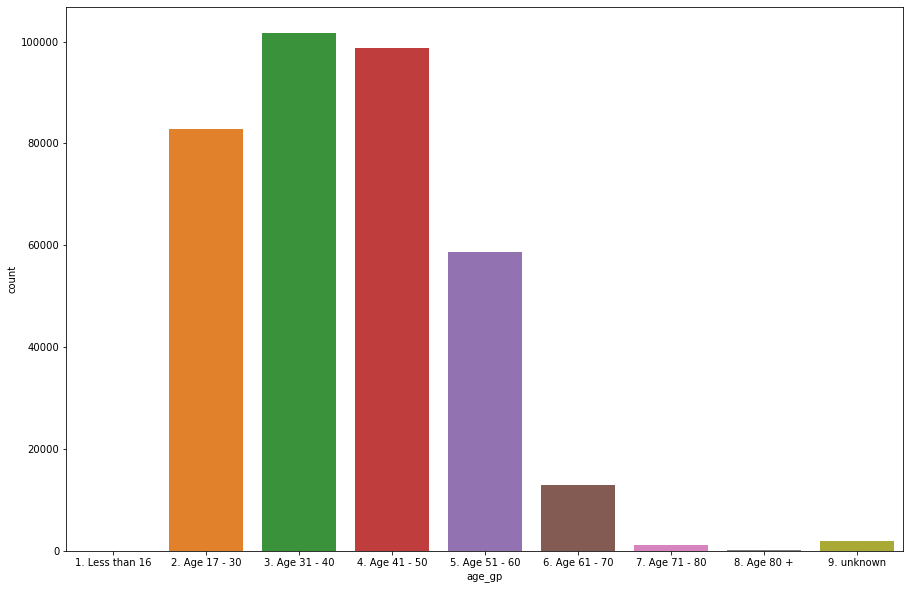

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
df=uniqueAge_GpForEachCustomerAndEachMedicPolicyNo 
# [ ~(uniqueAge_GpForEachCustomerAndEachPolicyNo['age_gp'] == 9999) ]
sns.countplot(x='age_gp',data =df)
plt.show()

# Merge with claimbase

In [1]:
CLAMBASE_FILE = os.path.join(PA_DATA_DIR, "clambase_df.parquet")

NameError: name 'os' is not defined